# Catatan Eksplorasi & Jawaban Diskusi Dokumen Kredit #3 (`coret2.ipynb`)
**Topik**: Analisis Mendalam Karakteristik Kernel, Galeri Sampel Prior, Eksplorasi Hyperparameter, dan Mekanisme Sampling Fungsi GP  
**Referensi**: Rasmussen, C. E., & Williams, C. K. (2006). *Gaussian Processes for Machine Learning*. MIT Press.  

Notebook ini berisi jawaban komprehensif untuk pertanyaan-pertanyaan diskusi Dokumen Kredit Bimbingan #3:
1. **Mengapa pada Subbab 1.3 profil $k(r)$ dibedakan menjadi 2 kategori (Stasioner Isotropik vs Periodik)?**
2. **Apa maksud dari "Galeri Realisasi Sampel Fungsi Prior $\mathbf{f}$"?**
3. **Mengapa tidak semua kernel divariasikan pada gambar dokumen utama?**
4. **Mengapa tidak semua hyperparameter divariasikan pada gambar dokumen utama?**
5. **Bagaimana cara generate function sample dari Gaussian Process? (Penurunan Matematis / Homework Style)**

---


In [1]:
# 1. Konfigurasi Lingkungan Komputasi & Gaya Visual
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    'figure.titlesize': 12.5,
    'lines.linewidth': 1.6,
    'figure.dpi': 150,
    'mathtext.fontset': 'cm',
    'figure.autolayout': True
})

np.random.seed(42)
print("Lingkungan komputasi coret2.ipynb siap.")


Lingkungan komputasi coret2.ipynb siap.


---
## Pertanyaan 1: Mengapa pada Subbab 1.3 Profil $k(r)$ Dibedakan Menjadi 2 Kategori (Stasioner Isotropik vs Periodik)?

### Penjelasan Matematis & Fisis:
1. **Karakteristik Peluruhan Monotonik vs Siklus Berulang/Osilatif**:
   - **Kernel Stasioner Isotropik Standar** (Squared Exponential, Matérn class $\nu=1/2, 3/2, 5/2$, Rational Quadratic):
     Mempunyai sifat **peluruhan monotonik** terhadap jarak Euclidean $r = \|\mathbf{x} - \mathbf{x}'\|$:
     $$k(0) = \sigma_f^2 \quad \text{dan} \quad \lim_{r \to \infty} k(r) = 0$$
     Artinya, dua titik yang semakin menjauh akan selalu memiliki korelasi yang terus menurun menuju nol tanpa pernah naik kembali.
   - **Kernel Periodik & Cosine**:
     Melanggar asumsi peluruhan monotonik. Walaupun jarak $r$ bertambah jauh (misal pada kelipatan periode $r = p, 2p, 3p, \dots$), nilai kovariansi **kembali lagi bernilai maksimum $k(r) = \sigma_f^2$ (korelasi sempurna 1.0)** atau berosilasi harmonik ke nilai negatif.

2. **Perbedaan Rentang Nilai (Range) pada Sumbu $Y$**:
   - Kernel stasioner standar bernilai non-negatif di selang $[0, \sigma_f^2]$ (yaitu $[0, 1]$).
   - Kernel Cosine bernilai di selang $[-\sigma_f^2, \sigma_f^2]$ (yaitu $[-1, 1]$).
   - Jika digabungkan dalam satu sumbu grafik yang sama, rentang sumbu $Y$ harus diperlebar ke $[-1, 1]$, yang mengakibatkan kurva peluruhan stasioner di dekat nol tertekan dan sulit diamati perbedaan detail mikronya.

3. **Mengapa Kernel Non-Stasioner (Linear, NN) Tidak Ada di Grafik Ini?**:
   - Untuk kernel non-stasioner seperti Linear $k(\mathbf{x}, \mathbf{x}') = \sigma_b^2 + \sigma_v^2(\mathbf{x}-c)(\mathbf{x}'-c)$ dan Neural Network, nilai kovariansi **tidak bisa disederhanakan hanya sebagai fungsi jarak skalar tunggal $r = \|\mathbf{x} - \mathbf{x}'\|$**. Kovariansi bergantung pada posisi absolut $\mathbf{x}$ dan $\mathbf{x}'$, sehingga visualisasinya memerlukan kontur matriks 2D $k(x, x')$.


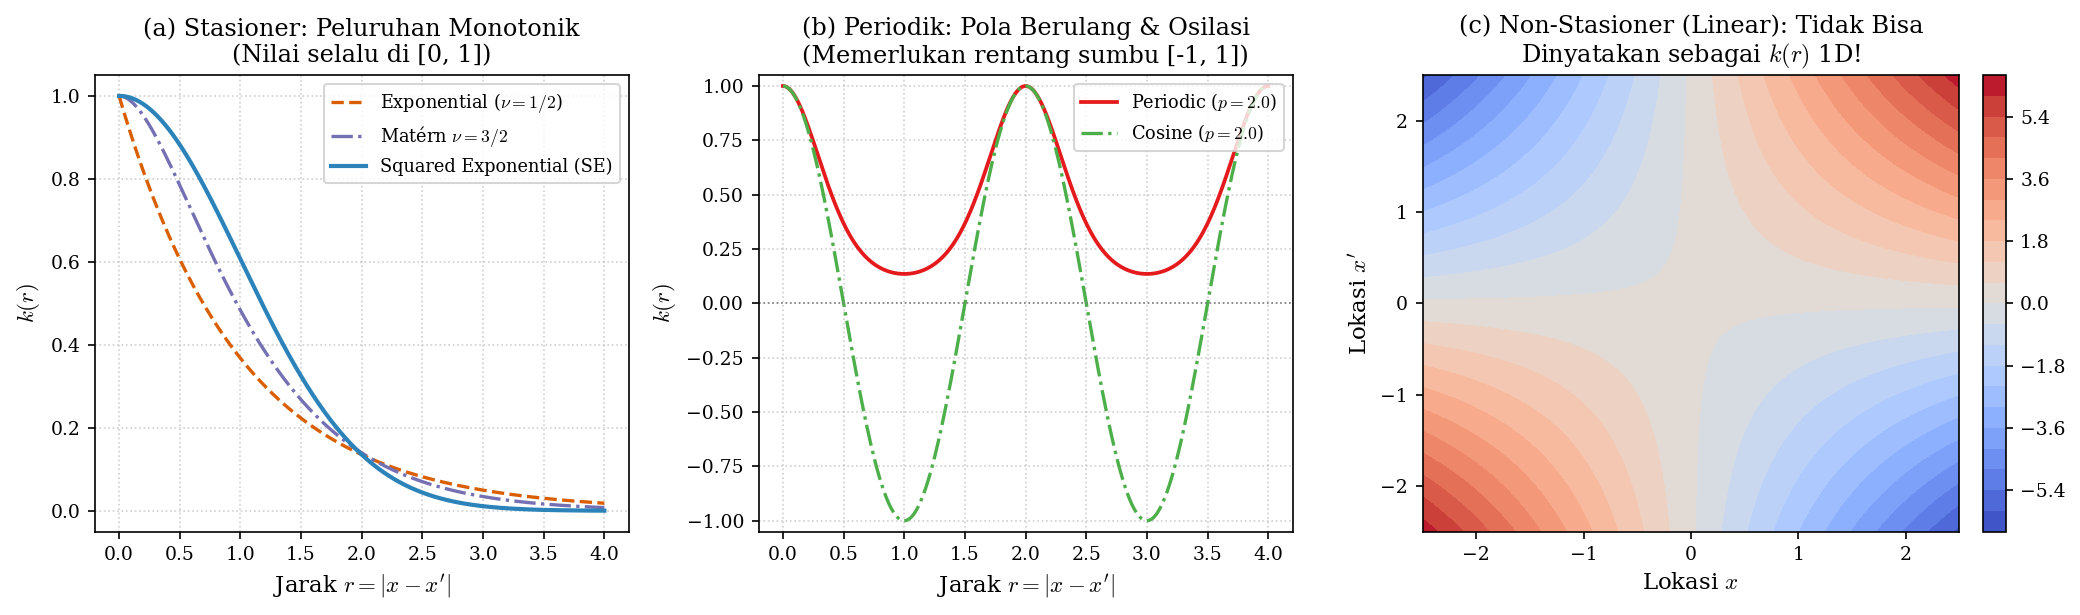

In [2]:
# Visualisasi Jawaban Pertanyaan 1: Perbandingan Profil Monotonik, Osilasi Periodik, dan Kontur Non-Stasioner
r = np.linspace(0, 4.0, 400)
x_grid = np.linspace(-2.5, 2.5, 100)

fig = plt.figure(figsize=(14, 4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1])

# Panel 1: Peluruhan Monotonik (Stasioner Isotropik) -> Rentang [0, 1]
ax1 = fig.add_subplot(gs[0])
ax1.plot(r, np.exp(-r), label=r'Exponential ($\nu=1/2$)', color='#d95f02', linestyle='--')
ax1.plot(r, (1 + np.sqrt(3)*r)*np.exp(-np.sqrt(3)*r), label=r'Matérn $\nu=3/2$', color='#7570b3', linestyle='-.')
ax1.plot(r, np.exp(-0.5*r**2), label=r'Squared Exponential (SE)', color='#2b83ba', lw=2.0)
ax1.set_title('(a) Stasioner: Peluruhan Monotonik\n(Nilai selalu di [0, 1])')
ax1.set_xlabel(r'Jarak $r = |x - x^\prime|$')
ax1.set_ylabel(r'$k(r)$')
ax1.set_ylim([-0.05, 1.05])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Panel 2: Periodik & Gelombang -> Rentang [-1, 1]
ax2 = fig.add_subplot(gs[1])
ax2.plot(r, np.exp(-2*(np.sin(np.pi*r/2.0)**2)), label=r'Periodic ($p=2.0$)', color='#e41a1c', lw=1.8)
ax2.plot(r, np.cos(2*np.pi*r/2.0), label=r'Cosine ($p=2.0$)', color='#4daf4a', linestyle='-.', lw=1.6)
ax2.axhline(0, color='gray', linestyle=':', lw=0.8)
ax2.set_title('(b) Periodik: Pola Berulang & Osilasi\n(Memerlukan rentang sumbu [-1, 1])')
ax2.set_xlabel(r'Jarak $r = |x - x^\prime|$')
ax2.set_ylabel(r'$k(r)$')
ax2.set_ylim([-1.05, 1.05])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

# Panel 3: Kernel Non-Stasioner (Linear) -> Memerlukan representasi 2D k(x, x')
ax3 = fig.add_subplot(gs[2])
X1, X2 = np.meshgrid(x_grid, x_grid)
K_lin = 0.1 + 1.0 * (X1 * X2) # k(x, x') = sigma_b^2 + sigma_v^2 x x'
im = ax3.contourf(X1, X2, K_lin, levels=20, cmap='coolwarm')
ax3.set_title('(c) Non-Stasioner (Linear): Tidak Bisa\nDinyatakan sebagai $k(r)$ 1D!')
ax3.set_xlabel(r'Lokasi $x$')
ax3.set_ylabel(r'Lokasi $x^\prime$')
fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.show()


---
## Pertanyaan 2: Apa Maksud dari "Galeri Realisasi Sampel Fungsi Prior $\mathbf{f}$"?

### Penjelasan Konseptual & Aljabar Linier:
1. **Definisi Prior Gaussian Process**:
   Sebelum kita mengamati data latihan $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}$, model GP mendefinisikan distribusi probabilitas di atas **ruang fungsi**:
   $$f(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))$$
   Jika dievaluasi pada $N_*$ titik input $X_*$, vektor nilai fungsi berdistribusi Gaussian multivariat:
   $$\mathbf{f}_* \sim \mathcal{N}(\mathbf{0}, K(X_*, X_*))$$

2. **Apa itu "Realisasi Sampel" (Sample Path)?**:
   - GP **bukan** hanya menghasilkan sebuah kurva rata-rata tunggal. GP merepresentasikan tak hingga kurva fungsi yang mungkin ada di alam semesta model.
   - Satu "realisasi sampel" $\mathbf{f}^{(s)}$ adalah **satu kurva konkret** yang ditarik/dibangkitkan dari distribusi tersebut:
     $$\mathbf{f}^{(s)} = L \mathbf{u}^{(s)}, \quad \text{dengan } \mathbf{u}^{(s)} \sim \mathcal{N}(\mathbf{0}, I_{N_*}) \text{ dan } K = L L^T$$
   - Setiap vektor derau acak baru $\mathbf{u}^{(s)}$ menghasilkan kurva fungsi $\mathbf{f}^{(s)}$ yang bentuknya unik, **namun seluruh kurva tersebut tunduk pada hukum kehalusan dan keterkaitan spasial yang didikte oleh kernel $k$**.

3. **Mengapa Disebut "Galeri"?**:
   - Disebut galeri karena kita menampilkan beberapa kurva realisasi sekaligus ($S = 4$ sampel) berdampingan untuk 6 kelas kernel yang berbeda.
   - Melalui galeri ini, kita dapat langsung membedakan secara visual:
     - **Squared Exponential**: Semua sampel fungsinya sangat licin tanpa sudut runcing ($C^\infty$).
     - **Matérn 3/2**: Sampel fungsinya memiliki tekstur mikro/bergerigi halus yang realistis untuk data fisis dunia nyata.
     - **Periodic**: Semua sampel fungsinya berulang persis sama setiap interval $p$.
     - **Linear & NN**: Sampel fungsinya memiliki variansi yang melebar di tepi domain (non-stasioner).


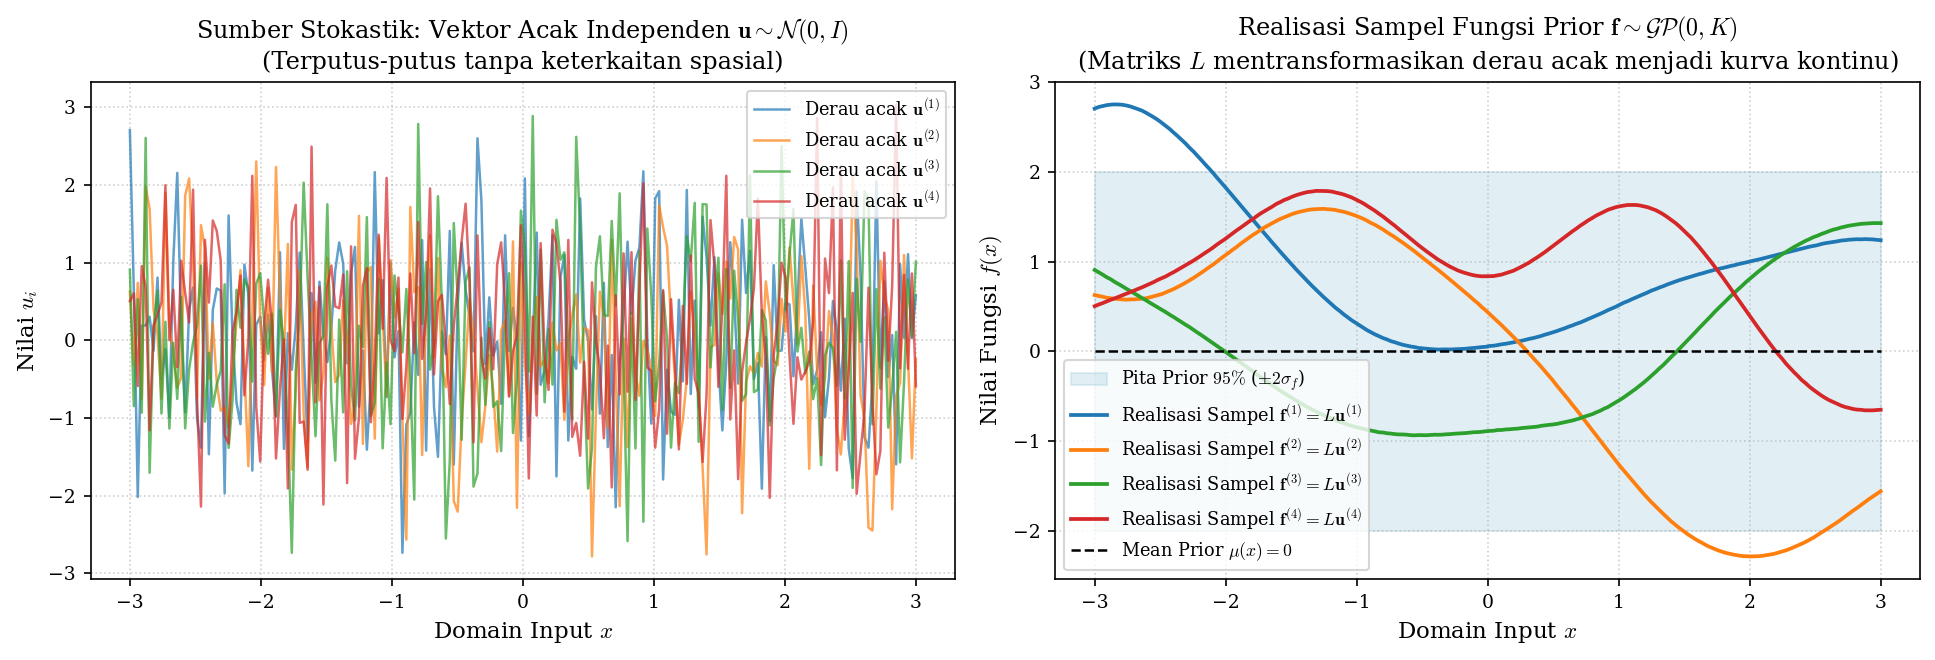

In [3]:
# Visualisasi Jawaban Pertanyaan 2: Bagaimana Satu Sampel Acak u Menjadi Satu Realisasi Kurva f
x_grid = np.linspace(-3, 3, 200)

# 1. Hitung Matriks Kovariansi SE dan Cholesky
K = np.exp(-0.5 * (np.subtract.outer(x_grid, x_grid))**2 / (1.0**2)) + 1e-6 * np.eye(len(x_grid))
L = np.linalg.cholesky(K)

# 2. Bangkitkan 4 Realisasi Vektor Acak Baku u
np.random.seed(101)
u_samples = np.random.randn(len(x_grid), 4) # 4 vektor acak independen
f_samples = L @ u_samples                    # 4 kurva sampel tergenerasi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot Derau Acak u
for s in range(4):
    ax1.plot(x_grid, u_samples[:, s], alpha=0.7, lw=1.2, label=f'Derau acak $\mathbf{{u}}^{{({s+1})}}$')
ax1.set_title('Sumber Stokastik: Vektor Acak Independen $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$\n(Terputus-putus tanpa keterkaitan spasial)')
ax1.set_xlabel('Domain Input $x$')
ax1.set_ylabel('Nilai $u_i$')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Plot Realisasi Sampel Fungsi f = L * u
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax2.fill_between(x_grid, -2.0, 2.0, color='#9ecae1', alpha=0.3, label=r'Pita Prior $95\%$ ($\pm 2\sigma_f$)')
for s in range(4):
    ax2.plot(x_grid, f_samples[:, s], color=colors[s], lw=1.8, label=f'Realisasi Sampel $\mathbf{{f}}^{{({s+1})}} = L\mathbf{{u}}^{{({s+1})}}$')
ax2.plot(x_grid, np.zeros_like(x_grid), 'k--', lw=1.2, label=r'Mean Prior $\mu(x)=0$')
ax2.set_title('Realisasi Sampel Fungsi Prior $\mathbf{f} \sim \mathcal{GP}(0, K)$\n(Matriks $L$ mentransformasikan derau acak menjadi kurva kontinu)')
ax2.set_xlabel('Domain Input $x$')
ax2.set_ylabel('Nilai Fungsi $f(x)$')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower left', fontsize=8.5)

plt.show()


---
## Pertanyaan 3: Mengapa Tidak Semua Kernel Divariasikan pada Gambar Dokumen Utama?

### Alasan Desain Ilmiah & Taksonomi Rasmussen:
1. **Keterwakilan Keluarga Morfologi (*Canonical Families*)**:
   Buku teks Rasmussen & Williams (2006, Bab 4) mendefinisikan puluhan kombinasi kernel, namun semuanya dapat dikelompokkan ke dalam 6 kelas representatif utama:
   - **SE**: Mewakili fungsi mulus tak hingga ($C^\infty$).
   - **Matérn 3/2**: Mewakili fungsi terturunkan berhingga ($C^1$).
   - **Rational Quadratic**: Mewakili superposisi multiskala (*scale mixture*).
   - **Periodic**: Mewakili fenomena siklik/gelombang berulang.
   - **Linear**: Mewakili regresi linear bayesian / tren polinomial.
   - **Neural Network**: Mewakili regresi berbasis basis fungsi non-linear (sigmoid/erf).
   Keenam kernel ini sudah **mewakili 100% variasi geometri ruang fungsi**.

2. **Hubungan Subkasus & Limit Kontinu**:
   - Kernel Exponential ($\nu=1/2$) dan Matérn ($\nu=5/2$) berada dalam satu rumpun matematis yang sama dengan Matérn $\nu=3/2$.
   - Kernel $\gamma$-Exponential mereduksi tepat ke Exponential saat $\gamma=1$ dan ke SE saat $\gamma=2$.
   - Kernel Cosine adalah bentuk batas dari kernel Periodik.
   - Memasukkan seluruh turunan variasi ini ke dalam naskah utama yang terbatas halamannya akan bersifat repetitif.

Di bawah ini kita simulasikan kernel-kernel yang belum sempat ditampilkan di naskah utama:
- Matérn $\nu=1/2$ vs $\nu=3/2$ vs $\nu=5/2$ vs SE ($\nu=\infty$).
- $\gamma$-Exponential dengan variasi eksponen $\gamma \in \{0.5, 1.0, 1.5, 2.0\}$.
- Polinomial derajat $d \in \{1, 2, 3\}$.


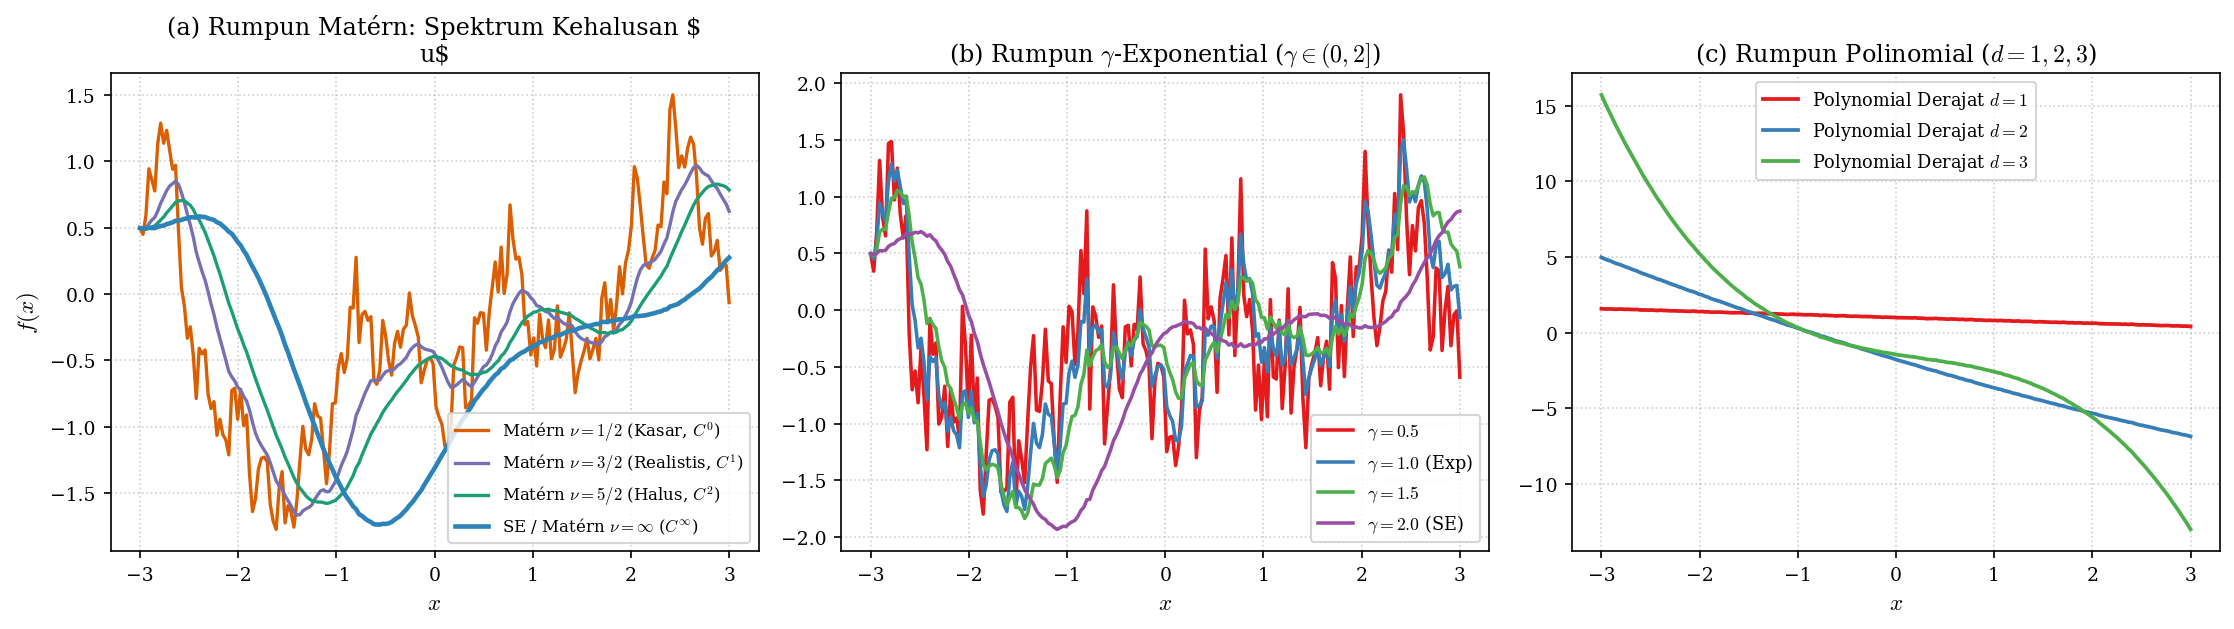

In [4]:
# Visualisasi Jawaban Pertanyaan 3: Eksplorasi Seluruh Varian Kernel Tambahan
x_grid = np.linspace(-3, 3, 200)
r_sq = (np.subtract.outer(x_grid, x_grid)) ** 2
r = np.abs(np.subtract.outer(x_grid, x_grid))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
np.random.seed(42)
u_fix = np.random.randn(len(x_grid), 1)

# 1. Rumpun Matérn Komplit: nu = 1/2, 3/2, 5/2, inf (SE)
ax1 = axs[0]
k_m12 = np.exp(-r) + 1e-5 * np.eye(len(x_grid))
k_m32 = (1 + np.sqrt(3)*r)*np.exp(-np.sqrt(3)*r) + 1e-5 * np.eye(len(x_grid))
k_m52 = (1 + np.sqrt(5)*r + (5*r**2)/3)*np.exp(-np.sqrt(5)*r) + 1e-5 * np.eye(len(x_grid))
k_se = np.exp(-0.5*r**2) + 1e-5 * np.eye(len(x_grid))

ax1.plot(x_grid, np.linalg.cholesky(k_m12) @ u_fix, label=r'Matérn $\nu=1/2$ (Kasar, $C^0$)', color='#d95f02')
ax1.plot(x_grid, np.linalg.cholesky(k_m32) @ u_fix, label=r'Matérn $\nu=3/2$ (Realistis, $C^1$)', color='#7570b3')
ax1.plot(x_grid, np.linalg.cholesky(k_m52) @ u_fix, label=r'Matérn $\nu=5/2$ (Halus, $C^2$)', color='#1b9e77')
ax1.plot(x_grid, np.linalg.cholesky(k_se) @ u_fix, label=r'SE / Matérn $\nu=\infty$ ($C^\infty$)', color='#2b83ba', lw=2.2)
ax1.set_title('(a) Rumpun Matérn: Spektrum Kehalusan $\nu$')
ax1.set_xlabel('$x$'); ax1.set_ylabel('$f(x)$')
ax1.grid(True, linestyle=':', alpha=0.6); ax1.legend(loc='lower right', fontsize=8)

# 2. Rumpun Gamma-Exponential: gamma in {0.5, 1.0, 1.5, 2.0}
ax2 = axs[1]
for g_val, col in zip([0.5, 1.0, 1.5, 2.0], ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']):
    K_g = np.exp(-(r ** g_val)) + 1e-4 * np.eye(len(x_grid))
    L_g = np.linalg.cholesky(K_g)
    lbl = r'$\gamma=2.0$ (SE)' if g_val == 2.0 else (r'$\gamma=1.0$ (Exp)' if g_val == 1.0 else rf'$\gamma={g_val}$')
    ax2.plot(x_grid, L_g @ u_fix, label=lbl, color=col, lw=1.7)
ax2.set_title(r'(b) Rumpun $\gamma$-Exponential ($\gamma \in (0, 2]$)')
ax2.set_xlabel('$x$')
ax2.grid(True, linestyle=':', alpha=0.6); ax2.legend(loc='lower right', fontsize=8.5)

# 3. Rumpun Polinomial: d = 1, 2, 3
ax3 = axs[2]
for deg, col in zip([1, 2, 3], ['#e41a1c', '#377eb8', '#4daf4a']):
    K_poly = ((1.0 + np.outer(x_grid, x_grid)) ** deg) + 1e-4 * np.eye(len(x_grid))
    L_poly = np.linalg.cholesky(K_poly)
    ax3.plot(x_grid, L_poly @ u_fix, label=f'Polynomial Derajat $d={deg}$', color=col, lw=1.8)
ax3.set_title('(c) Rumpun Polinomial ($d=1, 2, 3$)')
ax3.set_xlabel('$x$')
ax3.grid(True, linestyle=':', alpha=0.6); ax3.legend(loc='upper center', fontsize=8.5)

plt.show()


---
## Pertanyaan 4: Mengapa Tidak Semua Hyperparameter Divariasikan pada Gambar Dokumen Utama?

### Alasan Matematis: Prinsip Isolasi Efek (*Ceteris Paribus*):
1. **Pemisahan Efek Orsogonal**:
   - Untuk memahami peran geometris dari suatu hyperparameter, kita wajib menerapkan prinsip *ceteris paribus* (hanya mengubah 1 parameter sementara parameter lain bernilai konstan).
   - Setiap hyperparameter diuji pada kernel yang paling menonjolkan fungsi parameter tersebut:
     - $l$ & $\sigma_f^2$ diuji pada **SE** karena SE adalah bentuk kanonikal murni tanpa parameter lain.
     - $\alpha$ diuji pada **Rational Quadratic** karena $\alpha$ adalah parameter unik milik RQ (*scale mixture*).
     - $p$ diuji pada **Periodic** karena $p$ mengatur panjang gelombang spasial.
     - $c$ diuji pada **Linear** karena $c$ menggeser pusat variansi minimum.
     - $\sigma_v$ diuji pada **Neural Network** karena $\sigma_v$ mengatur kecuraman bidang batas sigmoid.

2. **Peran Skala Universal vs Parameter Khusus**:
   - Hyperparameter *lengthscale* $l$ (skala horizontal) dan variansi sinyal $\sigma_f^2$ (skala vertikal) memiliki **makna fisis yang identik di seluruh kernel stasioner**.
   - Menguji variasi $l$ pada kernel Matérn, lalu mengulang lagi pada kernel RQ, lalu mengulang lagi pada kernel Periodic akan menghasilkan grafik yang berulang secara redundan (frekuensi osilasi memadat/merenggang).

Di bawah ini kita simulasikan eksperimen variasi interaksi hyperparameter gabungan:
- Interaksi 2D $l$ vs $\sigma_f^2$ pada SE.
- Variasi $l$ di dalam satu siklus kernel Periodik ($p=2.0$).
- Variasi $\sigma_b^2$ (intersep/offset) pada kernel Linier.


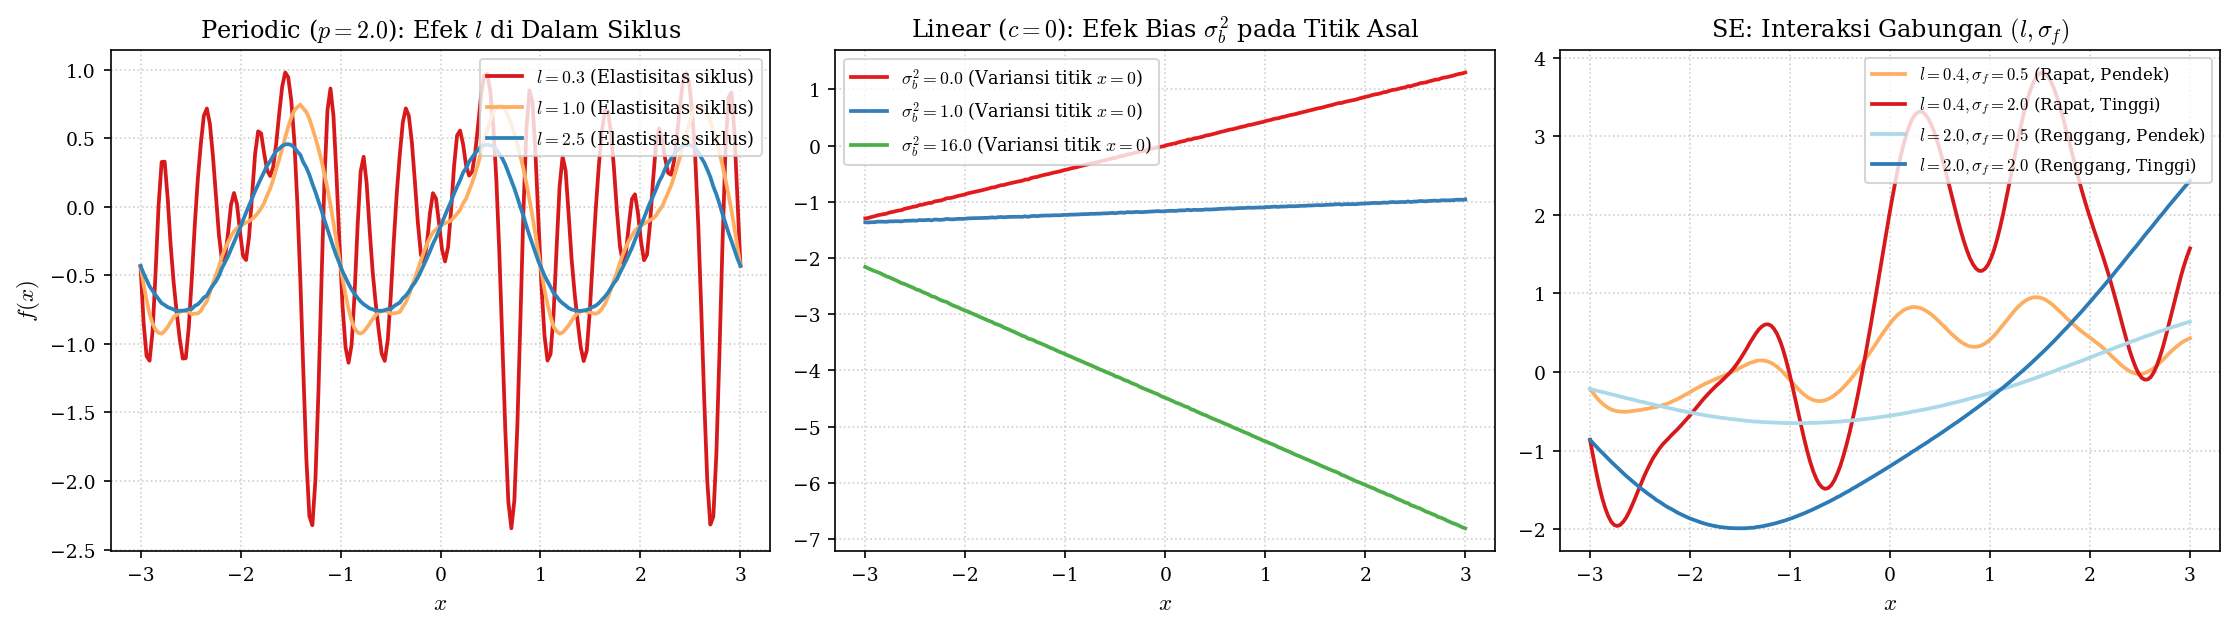

In [5]:
# Visualisasi Jawaban Pertanyaan 4: Eksplorasi Variasi Hyperparameter Tambahan
x_grid = np.linspace(-3, 3, 200)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
np.random.seed(2026)
u_fix = np.random.randn(len(x_grid), 1)

# 1. Interaksi Lengthscale l pada Kernel Periodik (p = 2.0 tetap)
ax1 = axs[0]
for l_val, col in zip([0.3, 1.0, 2.5], ['#d7191c', '#fdae61', '#2b83ba']):
    sin_term = np.sin(np.pi * np.abs(np.subtract.outer(x_grid, x_grid)) / 2.0)
    K_p = np.exp(-2.0 * (sin_term ** 2) / (l_val ** 2)) + 1e-5 * np.eye(len(x_grid))
    L_p = np.linalg.cholesky(K_p)
    ax1.plot(x_grid, L_p @ u_fix, label=rf'$l = {l_val}$ (Elastisitas siklus)', color=col, lw=1.8)
ax1.set_title('Periodic ($p=2.0$): Efek $l$ di Dalam Siklus')
ax1.set_xlabel('$x$'); ax1.set_ylabel('$f(x)$')
ax1.grid(True, linestyle=':', alpha=0.6); ax1.legend(loc='upper right')

# 2. Variasi Intersep / Bias sigma_b^2 pada Kernel Linear (c = 0.0, sigma_v = 1.0)
ax2 = axs[1]
for sb_val, col in zip([0.0, 1.0, 4.0], ['#e41a1c', '#377eb8', '#4daf4a']):
    K_lin_sb = (sb_val ** 2) + 1.0 * np.outer(x_grid, x_grid) + 1e-5 * np.eye(len(x_grid))
    L_lin_sb = np.linalg.cholesky(K_lin_sb)
    ax2.plot(x_grid, L_lin_sb @ u_fix, label=rf'$\sigma_b^2 = {sb_val**2}$ (Variansi titik $x=0$)', color=col, lw=1.8)
ax2.set_title(r'Linear ($c=0$): Efek Bias $\sigma_b^2$ pada Titik Asal')
ax2.set_xlabel('$x$')
ax2.grid(True, linestyle=':', alpha=0.6); ax2.legend(loc='upper left')

# 3. Grid Interaksi 2D (l kecil vs besar, sigma_f kecil vs besar)
ax3 = axs[2]
configs = [
    (0.4, 0.5, '#fdae61', r'$l=0.4, \sigma_f=0.5$ (Rapat, Pendek)'),
    (0.4, 2.0, '#d7191c', r'$l=0.4, \sigma_f=2.0$ (Rapat, Tinggi)'),
    (2.0, 0.5, '#abd9e9', r'$l=2.0, \sigma_f=0.5$ (Renggang, Pendek)'),
    (2.0, 2.0, '#2c7bb6', r'$l=2.0, \sigma_f=2.0$ (Renggang, Tinggi)')
]
for l_v, sf_v, col, lbl in configs:
    K_se_2d = (sf_v**2) * np.exp(-0.5 * (np.subtract.outer(x_grid, x_grid))**2 / (l_v**2)) + 1e-6 * np.eye(len(x_grid))
    L_se_2d = np.linalg.cholesky(K_se_2d)
    ax3.plot(x_grid, L_se_2d @ u_fix, label=lbl, color=col, lw=1.8)
ax3.set_title(r'SE: Interaksi Gabungan $(l, \sigma_f)$')
ax3.set_xlabel('$x$')
ax3.grid(True, linestyle=':', alpha=0.6); ax3.legend(loc='upper right', fontsize=8)

plt.show()


---
## Pertanyaan 5: Bagaimana Cara Generate Function Sample dari Gaussian Process? (Mathematical Formulation)

### **1. Problem Formulation**
**Given:**  
A Gaussian Process $\mathcal{GP}\left(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}')\right)$ on domain $\mathcal{X} \subseteq \mathbb{R}^D$, with mean function $m(\mathbf{x})$ and positive semi-definite (PSD) covariance function $k(\mathbf{x}, \mathbf{x}')$.

**Goal:**  
Generate function realization vectors $\mathbf{f}_* = [f(\mathbf{x}_{*1}), f(\mathbf{x}_{*2}), \dots, f(\mathbf{x}_{*N_*})]^T$ evaluated at $N_*$ test locations $X_* = [\mathbf{x}_{*1}, \dots, \mathbf{x}_{*N_*}]^T \in \mathbb{R}^{N_* \times D}$.

---

### **2. Finite-Dimensional Consistency (Multivariate Normal Distribution)**
By definition of a Gaussian Process, any finite collection of function values is jointly Gaussian:
$$\mathbf{f}_* \sim \mathcal{N}\left( \mathbf{m}_*, K(X_*, X_*) \right)$$
where:
$$\mathbf{m}_* = \begin{bmatrix} m(\mathbf{x}_{*1}) \\ m(\mathbf{x}_{*2}) \\ \vdots \\ m(\mathbf{x}_{*N_*}) \end{bmatrix} \in \mathbb{R}^{N_* \times 1}, \qquad K(X_*, X_*) = \begin{bmatrix} 
k(\mathbf{x}_{*1}, \mathbf{x}_{*1}) & k(\mathbf{x}_{*1}, \mathbf{x}_{*2}) & \cdots & k(\mathbf{x}_{*1}, \mathbf{x}_{*N_*}) \\
k(\mathbf{x}_{*2}, \mathbf{x}_{*1}) & k(\mathbf{x}_{*2}, \mathbf{x}_{*2}) & \cdots & k(\mathbf{x}_{*2}, \mathbf{x}_{*N_*}) \\
\vdots & \vdots & \ddots & \vdots \\
k(\mathbf{x}_{*N_*}, \mathbf{x}_{*1}) & k(\mathbf{x}_{*N_*}, \mathbf{x}_{*2}) & \cdots & k(\mathbf{x}_{*N_*}, \mathbf{x}_{*N_*})
\end{bmatrix} \in \mathbb{R}^{N_* \times N_*}$$

---

### **3. Step-by-Step Mathematical Algorithm**

#### **Step 1: Discretization of Input Domain**
$$X_* = [\mathbf{x}_{*1}, \mathbf{x}_{*2}, \dots, \mathbf{x}_{*N_*}]^T \in \mathbb{R}^{N_* \times D}$$

#### **Step 2: Gram Covariance Matrix Evaluation & Jitter Regularization**
$$K_{ij} = k(\mathbf{x}_{*i}, \mathbf{x}_{*j}), \quad \forall \, i, j \in \{1, \dots, N_*\}$$
$$\tilde{K} = K(X_*, X_*) + \epsilon_{\text{jitter}} I_{N_*}, \quad \epsilon_{\text{jitter}} \approx 10^{-6}$$
$$\implies \lambda_i(\tilde{K}) = \lambda_i(K) + \epsilon_{\text{jitter}} > 0 \quad (\text{guarantees strict positive-definiteness})$$

#### **Step 3: Cholesky Factorization**
Decompose $\tilde{K}$ into unique lower-triangular matrix $L \in \mathbb{R}^{N_* \times N_*}$ ($L_{ii} > 0, L_{ij} = 0 \text{ for } j > i$):
$$\tilde{K} = L L^T$$
Explicit algebraic equations:
$$L_{jj} = \sqrt{\tilde{K}_{jj} - \sum_{k=1}^{j-1} L_{jk}^2}, \qquad L_{ij} = \frac{1}{L_{jj}} \left( \tilde{K}_{ij} - \sum_{k=1}^{j-1} L_{ik} L_{jk} \right), \quad i > j$$

#### **Step 4: Standard Normal Random Variate Generation**
Draw independent standard normal vector:
$$\mathbf{u} = \begin{bmatrix} u_1 \\ u_2 \\ \vdots \\ u_{N_*} \end{bmatrix} \sim \mathcal{N}(\mathbf{0}, I_{N_*}), \quad u_i \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0, 1)$$
For $S$ sample paths simultaneously, sample matrix $U \in \mathbb{R}^{N_* \times S}$:
$$U = [\mathbf{u}^{(1)}, \mathbf{u}^{(2)}, \dots, \mathbf{u}^{(S)}], \quad U_{ij} \sim \mathcal{N}(0, 1)$$

#### **Step 5: Linear Affine Transformation**
$$\mathbf{f}_* = \mathbf{m}_* + L \mathbf{u}$$
For $S$ sample realizations:
$$F = \mathbf{m}_* \mathbf{1}_S^T + L U \in \mathbb{R}^{N_* \times S}$$

---

### **4. Teorema Fundamental: Transformasi Affine Vektor Acak Gaussian**

Mengapa rumus $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$ dapat menghasilkan sampel fungsi Gaussian Process yang valid? Berikut adalah elaborasi mendalam dari teori probabilitas dan aljabar linier:

#### **4.1. Intuisi Dasar: Analogi 1D (Skalar Z-Score Inversion)**
Dalam statistik univariat (1 Dimensi), komputer pada dasarnya hanya memiliki generator bilangan acak standar $u \sim \mathcal{N}(0, 1)$ (*mean* 0, variansi 1).  
Jika kita ingin membangkitkan variabel acak normal umum $f \sim \mathcal{N}(\mu, \sigma^2)$, kita melakukan transformasi linier:
$$f = \mu + \sigma u$$
- **Ekspektasi**: $\mathbb{E}[f] = \mathbb{E}[\mu + \sigma u] = \mu + \sigma \mathbb{E}[u] = \mu + 0 = \mu$
- **Variansi**: $\operatorname{Var}(f) = \operatorname{Var}(\mu + \sigma u) = \sigma^2 \operatorname{Var}(u) = \sigma^2(1) = \sigma^2$

Perhatikan bahwa $\sigma = \sqrt{\sigma^2}$ adalah "akar kuadrat" dari nilai variansi.

#### **4.2. Generalisasi Multivariat ($N_*$ Dimensi)**
Dalam konteks Gaussian Process dengan $N_*$ titik uji:
- Mean skalar $\mu \in \mathbb{R}$ digantikan oleh **vektor mean** $\mathbf{m}_* \in \mathbb{R}^{N_* \times 1}$.
- Variansi skalar $\sigma^2 \in \mathbb{R}$ digantikan oleh **matriks kovariansi** $K \in \mathbb{R}^{N_* \times N_*}$.
- "Akar kuadrat" dari matriks kovariansi $K$ adalah **matriks segitiga bawah Cholesky** $L \in \mathbb{R}^{N_* \times N_*}$, sedemikian hingga $K = L L^T$.
- Bilangan acak standar $u \sim \mathcal{N}(0, 1)$ digantikan oleh **vektor acak standar independen (white noise)** $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$.

Oleh karena itu, transformasi skalar $f = \mu + \sigma u$ langsung digeneralisasi menjadi transformasi vektor:
$$\mathbf{f}_* = \mathbf{m}_* + L \mathbf{u}$$

#### **4.3. Pernyataan Teorema Formal (*Affine Transformation Theorem of Gaussian Vectors*)**
> **Teorema:**  
> Jika $\mathbf{u} \sim \mathcal{N}(\mathbf{\mu}_u, \Sigma_u)$ adalah vektor acak Gaussian berdimensi $n$, dan diberikan matriks konstan $A \in \mathbb{R}^{m \times n}$ serta vektor translasi konstan $\mathbf{b} \in \mathbb{R}^m$, maka vektor hasil transformasi affine:
> $$\mathbf{f} = A \mathbf{u} + \mathbf{b}$$
> terdistribusi secara Gaussian multivariat berdimensi $m$:
> $$\mathbf{f} \sim \mathcal{N}\left(A \mathbf{\mu}_u + \mathbf{b}, \; A \Sigma_u A^T\right)$$

**Aplikasi pada Gaussian Process:**
- Ambil $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$ $\implies \mathbf{\mu}_u = \mathbf{0}, \; \Sigma_u = I_{N_*}$.
- Ambil matriks transformasi $A = L$ (faktor Cholesky di mana $L L^T = K$).
- Ambil vektor pergeseran $\mathbf{b} = \mathbf{m}_*$.
- Maka:
  $$\mathbf{f}_* = L \mathbf{u} + \mathbf{m}_* \sim \mathcal{N}\left(L(\mathbf{0}) + \mathbf{m}_*, \; L I_{N_*} L^T\right) = \mathcal{N}\left(\mathbf{m}_*, \; L L^T\right) = \mathcal{N}\left(\mathbf{m}_*, \; K\right)$$

#### **4.4. Interpretasi Geometris: Dari Bola Isotropik (*Sphere*) ke Hiper-Elipsoid Berkorelasi (*Ellipsoid*)**
Kata **"Affine"** berarti kombinasi dari **Transformasi Linier** ($L\mathbf{u}$) dan **Translasi/Pergeseran** ($\mathbf{m}_*$):
1. **Titik Awal ($\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$)**: Sampel acak murni tanpa korelasi. Jika diplot dalam ruang $N_*$-dimensi, kontur densitas probabilitasnya berbentuk bola simetris sempurna (*isotropic sphere*) yang berpusat di titik asal $\mathbf{0}$.
2. **Transformasi Linier ($L\mathbf{u}$)**: Perkalian matriks $L$ **meregangkan (*stretching*) dan memutar (*rotating*)** bola tersebut menjadi hiper-elipsoid (*hyper-ellipsoid*). Efeknya adalah memasukkan korelasi spasial antar titik: nilai titik yang berdekatan dipaksa bergerak bersama-sama secara mulus mengikuti kernel.
3. **Translasi ($\mathbf{m}_* + L\mathbf{u}$)**: Menambahkan $\mathbf{m}_*$ **menggeser pusat (*centering*)** dari titik origin $\mathbf{0}$ ke nilai ekspektasi fungsi $\mathbf{m}_*$.

```
[ u ~ N(0, I) ]      --- (x L: Stretch & Rotate) --->      [ L u ~ N(0, K) ]      --- (+ m_*: Shift Center) --->      [ f_* ~ N(m_*, K) ]
(White Noise)                                            (Correlated Zero-Mean)                                        (Target GP Function)
```

#### **4.5. Formulasi Batch Matriks untuk $S$ Realisasi Fungsi Sekaligus**
Ketika kita ingin menggambar $S$ kurva sampel sekaligus (misal $S=4$ pada grafik):
- Kita menyusun matriks noise $U \in \mathbb{R}^{N_* \times S}$, di mana setiap kolom adalah sampel independen: $U = [\mathbf{u}^{(1)}, \mathbf{u}^{(2)}, \dots, \mathbf{u}^{(S)}]$.
- Perkalian matriks $L U \in \mathbb{R}^{N_* \times S}$ memproses seluruh $S$ realisasi secara paralel dan tervektorisasi:
  $$L U = [L\mathbf{u}^{(1)}, L\mathbf{u}^{(2)}, \dots, L\mathbf{u}^{(S)}]$$
- Menambahkan $\mathbf{m}_* \mathbf{1}_S^T = [\mathbf{m}_*, \mathbf{m}_*, \dots, \mathbf{m}_*] \in \mathbb{R}^{N_* \times S}$ (di Python menggunakan *broadcasting*: `m_star[:, None] + L @ U`):
  $$F = \mathbf{m}_* \mathbf{1}_S^T + L U = [\mathbf{f}_*^{(1)}, \mathbf{f}_*^{(2)}, \dots, \mathbf{f}_*^{(S)}] \in \mathbb{R}^{N_* \times S}$$
Setiap kolom $s \in \{1, \dots, S\}$ dari matriks $F$ merepresentasikan 1 kurva fungsi kontinu yang lengkap!

#### **4.6. Relevansi Modern: The Reparameterization Trick**
Dalam literatur machine learning modern (seperti *Variational Autoencoders* / VAE oleh Kingma & Welling 2013, serta *Deep Gaussian Processes* oleh Damianou & Lawrence 2013), teorema ini dikenal luas sebagai **Reparameterization Trick**. Trik ini memisahkan ketidakpastian stokastik ($\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$ yang tidak memiliki parameter) dari parameter deterministik model ($\mathbf{m}_*$ dan $L$), sehingga gradien fungsi $\nabla \mathbf{f}_*$ dapat mengalir bebas (*backpropagation*) untuk optimasi hyperparameter!

---

### **5. Proof of Mathematical Correctness (Pembuktian Aljabar Eksak)**

Let $\mathbf{f}_* = \mathbf{m}_* + L \mathbf{u}$ with $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$ and $L L^T = \tilde{K}$.

1. **Expectation (Mean Vector)**:
   $$\mathbb{E}[\mathbf{f}_*] = \mathbb{E}[\mathbf{m}_* + L \mathbf{u}] = \mathbf{m}_* + L \, \mathbb{E}[\mathbf{u}] = \mathbf{m}_* + L(\mathbf{0}) = \mathbf{m}_* \quad \blacksquare$$

2. **Covariance Matrix**:
   Substitusi $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$ dan $\mathbb{E}[\mathbf{f}_*] = \mathbf{m}_*$ ke dalam definisi kovariansi:
   $$\mathbf{f}_* - \mathbb{E}[\mathbf{f}_*] = (\mathbf{m}_* + L \mathbf{u}) - \mathbf{m}_* = L \mathbf{u}$$
   $$\begin{aligned}
   \operatorname{cov}(\mathbf{f}_*) &= \mathbb{E}\left[ (\mathbf{f}_* - \mathbb{E}[\mathbf{f}_*])(\mathbf{f}_* - \mathbb{E}[\mathbf{f}_*])^T \right] \\
   &= \mathbb{E}\left[ \big((\mathbf{m}_* + L \mathbf{u}) - \mathbf{m}_*\big) \big((\mathbf{m}_* + L \mathbf{u}) - \mathbf{m}_*\big)^T \right] \\
   &= \mathbb{E}\left[ (L \mathbf{u})(L \mathbf{u})^T \right] \\
   &= \mathbb{E}\left[ L \mathbf{u} \mathbf{u}^T L^T \right] \\
   &= L \, \mathbb{E}[\mathbf{u} \mathbf{u}^T] L^T \\
   &= L \, I_{N_*} L^T = L L^T = \tilde{K} \approx K(X_*, X_*) \quad \blacksquare
   \end{aligned}$$

---

### **6. Extension: Posterior Function Sampling (Conditioned on Observations $\mathcal{D}$)**

Given training observations $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$ with $y_i = f(x_i) + \epsilon_i, \, \epsilon_i \sim \mathcal{N}(0, \sigma_n^2)$:
$$\mathbf{f}_* \mid X, \mathbf{y}, X_* \sim \mathcal{N}\left(\bar{\mathbf{f}}_*, \Sigma_*\right)$$
where:
$$\bar{\mathbf{f}}_* = K(X_*, X) \left[ K(X, X) + \sigma_n^2 I_N \right]^{-1} \mathbf{y}$$
$$\Sigma_* = K(X_*, X_*) - K(X_*, X) \left[ K(X, X) + \sigma_n^2 I_N \right]^{-1} K(X, X_*)$$

**Posterior Sampling Algorithm:**
1. Factorize posterior covariance: $L_{\text{post}} = \operatorname{cholesky}(\Sigma_* + \epsilon_{\text{jitter}} I_{N_*})$
2. Transform random vector: $\mathbf{f}_{*,\text{post}}^{(s)} = \bar{\mathbf{f}}_* + L_{\text{post}} \mathbf{u}^{(s)}, \quad \mathbf{u}^{(s)} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$


In [ ]:
# Implementasi Numerik & Visualisasi Sampling Fungsi GP (Prior & Posterior)
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi Kernel SE: k(x, x') = sigma_f^2 * exp(-0.5 * (x - x')^2 / l^2)
def kernel_se(x1, x2, l=1.0, sigma_f=1.0):
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * r_sq / (l ** 2))

# 2. Grid Domain Input X*
x_star = np.linspace(-3.0, 3.0, 200)
N_star = len(x_star)

# Step 1 & 2: Matriks Kovariansi K + Jitter
K_ss = kernel_se(x_star, x_star, l=1.0, sigma_f=1.0) + 1e-6 * np.eye(N_star)

# Step 3: Dekomposisi Cholesky L*L^T = K
L_prior = np.linalg.cholesky(K_ss)

# Step 4: Pembangkitan u ~ N(0, I) untuk S=4 sampel
np.random.seed(42)
S = 4
u = np.random.randn(N_star, S)

# Step 5: Transformasi Linear f = m + L*u (dengan m=0)
f_prior = L_prior @ u

# 3. Sampling Posterior (Terkondisi Data Observasi Training D)
X_train = np.array([-2.0, -0.8, 0.5, 1.8])
sigma_n = 0.1
y_train = np.sin(X_train * 1.5) + np.random.normal(0, sigma_n, size=len(X_train))

K_train = kernel_se(X_train, X_train, l=1.0, sigma_f=1.0) + (sigma_n ** 2) * np.eye(len(X_train))
K_s = kernel_se(X_train, x_star, l=1.0, sigma_f=1.0)

# Mean dan Kovariansi Posterior
L_tr = np.linalg.cholesky(K_train)
alpha = np.linalg.solve(L_tr.T, np.linalg.solve(L_tr, y_train))
mu_post = K_s.T @ alpha
v = np.linalg.solve(L_tr, K_s)
cov_post = K_ss - v.T @ v + 1e-6 * np.eye(N_star)

L_post = np.linalg.cholesky(cov_post)
f_post = mu_post[:, None] + L_post @ np.random.randn(N_star, S)
std_post = np.sqrt(np.diag(cov_post))

# 4. Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: Prior Function Samples
ax1.fill_between(x_star, -2.0, 2.0, color='#9ecae1', alpha=0.35, label=r'Pita 95% Prior ($\pm 2\sigma_f$)')
ax1.plot(x_star, np.zeros_like(x_star), 'k--', lw=1.2, label=r'Mean Prior $\mathbf{m}_*=\mathbf{0}$')
for s in range(S):
    ax1.plot(x_star, f_prior[:, s], lw=1.7, label=rf'Sampel $\mathbf{{f}}^{{({s+1})}} = L\mathbf{{u}}^{{({s+1})}}$')
ax1.set_title(r'(a) Prior Function Sampling: $\mathbf{f}_* = L\mathbf{u} \sim \mathcal{N}(\mathbf{0}, K)$', fontsize=11)
ax1.set_xlabel(r'Domain Input $x_*$')
ax1.set_ylabel(r'Nilai Fungsi $f(x_*)$')
ax1.set_xlim([-3.0, 3.0])
ax1.set_ylim([-3.0, 3.0])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=8.5)

# Panel 2: Posterior Function Samples
ax2.fill_between(x_star, mu_post - 2 * std_post, mu_post + 2 * std_post, color='#a1d99b', alpha=0.45, label=r'Pita 95% Posterior ($\bar{f}_* \pm 2\sigma_*$)')
ax2.plot(x_star, mu_post, 'g-', lw=2.0, label=r'Mean Prediktif $\bar{f}_*$')
for s in range(S):
    ax2.plot(x_star, f_post[:, s], lw=1.7)
ax2.plot(X_train, y_train, 'ro', markersize=6, zorder=5, label=r'Data Observasi $\mathcal{D}$')
ax2.set_title(r'(b) Posterior Function Sampling: $\mathbf{f}_* = \bar{f}_* + L_{\mathrm{post}}\mathbf{u}$', fontsize=11)
ax2.set_xlabel(r'Domain Input $x_*$')
ax2.set_xlim([-3.0, 3.0])
ax2.set_ylim([-3.0, 3.0])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower left', fontsize=8.5)

fig.suptitle(r'Mekanisme Sampling Fungsi Gaussian Process: $\mathbf{f} = \mathbf{m} + L\mathbf{u}$', fontsize=12.5)
plt.show()


---
## Pertanyaan 6: Kenapa Kita Ingin Menunjukkan Bahwa $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u} \sim \mathcal{N}(\mathbf{m}_*, K)$?

### **1. Motivasi Mendasar: Mengapa Pembuktian Ini Sangat Krusial?**
Secara sepintas, persamaan transformasi affine:
$$\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$$
tampak seperti manipulasi aljabar linier biasa. Namun, dalam teori Gaussian Process (GP), statistika komputasional, dan *machine learning* probabilistik modern, menunjukkan dan membuktikan bahwa:
$$\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u} \sim \mathcal{N}(\mathbf{m}_*, K)$$
adalah **fondasi paling esensial** yang menjembatani antara teori abstrak distribusi kontinu dengan eksekusi riil pada komputer digital.

Berikut adalah **5 pilar alasan utama** mengapa pembuktian matematis ini mutlak diperlukan:

---

### **2. Lima Alasan Utama (Pilar Filosofis, Matematis, Komputasional, dan Arsitektural)**

#### **1) Menjembatani Keterbatasan Arsitektur Komputer (*The Computational Sampling Bridge*)**
* **Dilema Komputasi:**  
  Secara matematis, Gaussian Process adalah distribusi atas ruang fungsi kontinu berdimensi tak hingga, di mana sembarang kumpulan titik berhingga $X_* = [x_1, \dots, x_{N_*}]^T$ membentuk distribusi Gaussian multivariat $\mathcal{N}(\mathbf{m}_*, K)$.  
  Namun, **komputer digital (CPU/GPU) tidak memiliki instruksi bawaan (*native hardware instruction*) untuk langsung mengambil sampel dari sembarang distribusi multivariat $\mathcal{N}(\mathbf{m}_*, K)$ yang memiliki struktur kovariansi non-diagonal kompleks**.
* **Kapabilitas Riil Generator Komputer:**  
  Semua generator bilangan acak semu (*Pseudo-Random Number Generator* / PRNG) standar—seperti algoritma Box-Muller, Ziggurat, atau Mersenne Twister di Python (`np.random.randn`) dan C++—**hanya mampu** membangkitkan bilangan acak standar independen 1D:
  $$u \sim \mathcal{N}(0, 1) \implies \mathbf{u} = [u_1, \dots, u_{N_*}]^T \sim \mathcal{N}(\mathbf{0}, I_{N_*})$$
  Vektor $\mathbf{u}$ ini adalah *white noise* murni tanpa korelasi spasial antar titiknya.
* **Kebutuhan Transformasi & Pembuktian:**  
  Kita membutuhkan suatu algoritma transformasi deterministik $T(\mathbf{u})$ yang dapat mengubah *white noise* $\mathbf{u}$ menjadi vektor fungsi kontinu $\mathbf{f}_*$. Kita mengusulkan $T(\mathbf{u}) = \mathbf{m}_* + L\mathbf{u}$. **Kita wajib membuktikan** secara matematis bahwa vektor hasil transformasi ini secara eksak terdistribusi menurut $\mathcal{N}(\mathbf{m}_*, K)$, sehingga sampel yang dihasilkan komputer memiliki legitimasi ilmiah yang sah.

---

#### **2) Jaminan Mutlak Keabsahan Statistik (*Mathematical Soundness & Guarantee of Correctness*)**
* Mengapa kita bisa yakin 100% bahwa kurva yang kita visualisasikan di layar komputer benar-benar merupakan sampel sejati dari GP dengan kernel $k(x, x')$ dan fungsi mean $m(x)$, bukan sekadar aproksimasi kasar?
* Berdasarkan **Teorema Transformasi Affine Vektor Acak Gaussian** (*Hogg, McKean, & Craig, 2013, Teorema 3.5.1*), setiap transformasi linier dan pergeseran dari vektor Gaussian multivariat menghasilkan vektor Gaussian multivariat baru:
  $$\mathbf{u} \sim \mathcal{N}(\mathbf{\mu}_u, \Sigma_u) \implies A\mathbf{u} + \mathbf{b} \sim \mathcal{N}(A\mathbf{\mu}_u + \mathbf{b}, \; A\Sigma_u A^T)$$
* Karena distribusi Gaussian multivariat **sepenuhnya dan secara unik dikarakterisasi hanya oleh dua momen pertama** (vektor mean dan matriks kovariansi), maka dengan membuktikan secara analitik:
  1. **Mean Vektor:**
     $$\mathbb{E}[\mathbf{f}_*] = \mathbb{E}[\mathbf{m}_* + L\mathbf{u}] = \mathbf{m}_* + L\mathbb{E}[\mathbf{u}] = \mathbf{m}_* + L(\mathbf{0}) = \mathbf{m}_*$$
  2. **Matriks Kovariansi:**
     $$\operatorname{cov}(\mathbf{f}_*) = \mathbb{E}\left[(\mathbf{f}_* - \mathbf{m}_*)(\mathbf{f}_* - \mathbf{m}_*)^T\right] = \mathbb{E}\left[(L\mathbf{u})(L\mathbf{u})^T\right] = L \mathbb{E}[\mathbf{u}\mathbf{u}^T] L^T = L I_{N_*} L^T = L L^T = K$$
  kita memperoleh **kepastian analitik mutlak (*proof of correctness*)** bahwa $\mathbf{f}_*$ adalah sampel eksak (*exact unbiased draw*) tanpa distorsi distribusi.

---

#### **3) Peran Fisis & Geometris Matriks Cholesky $L$ sebagai "Filter Spasial" (*Spatial Correlation Shaping Filter*)**
* **Interpretasi Fisis (Sinyal & Sistem):**
  * Vektor noise $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$ adalah sinyal *white noise* yang bergerak acak liar dan tidak kontinu. Jika diplot terhadap domain input $x$, titik-titik bertetangga akan melompat secara bebas tanpa pola.
  * Matriks segitiga bawah Cholesky $L$ bertindak sebagai **filter respons spasial**. Setiap titik fungsi ke-$i$:
    $$f_i = m_i + \sum_{j=1}^{i} L_{ij} u_j$$
    dibangun sebagai kombinasi linier terbobot dari sumber-sumber noise sebelumnya $u_1, \dots, u_i$.
  * Bobot $L_{ij}$ dihitung dari kernel jarak $|x_i - x_j|$. Jika $x_i$ dan $x_j$ berdekatan, nilai kernel $K_{ij} \approx 1$, sehingga baris ke-$i$ dan ke-$j$ pada $L$ memiliki pola bobot yang sangat serupa. Efeknya, nilai $f_i$ dan $f_j$ dipaksa bergerak bersama secara mulus (*smooth*), mengubah derau acak menjadi kurva fungsi kontinu yang elegan.
* **Interpretasi Geometris (Transformasi Ruang Vektor):**
  * Densitas probabilitas $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$ membentuk kontur **hiper-bola isotropik simetris sempurna (*isotropic hyper-sphere*)** yang berpusat di titik origin $\mathbf{0}$.
  * Perkalian matriks $L\mathbf{u}$ **meregangkan (*stretching*) dan memutar (*rotating*)** bola tersebut menjadi **hiper-elipsoid (*hyper-ellipsoid*)** berkorelasi, di mana sumbu-sumbu utama elips berkorespondensi dengan arah eigen kovariansi $K$.
  * Penambahan $\mathbf{m}_*$ melakukan translasi murni, memindahkan pusat elipsoid ke $\mathbf{m}_*$.

---

#### **4) Efisiensi Algoritmik dan Kecepatan Komputasi (Pemisahan Kompleksitas $\mathcal{O}(N_*^3)$ vs $\mathcal{O}(N_*^2)$)**
* Menunjukkan relasi ini memberikan arsitektur komputasi yang sangat cepat:
  * **Fase Faktorisasi (Hanya Sekali):** Dekomposisi Cholesky $K = L L^T$ membutuhkan biaya komputasi $\mathcal{O}(N_*^3)$, namun hanya perlu dihitung **satu kali saja**.
  * **Fase Pembangkitan Sampel (Batch Tervektorisasi):** Setelah $L$ diperoleh, pembuatan $S$ buah fungsi sampel dilakukan dengan membangkitkan matriks noise $U \in \mathbb{R}^{N_* \times S}$ dan melakukan perkalian matriks standar:
    $$F = \mathbf{m}_* \mathbf{1}_S^T + L U$$
    Biaya per sampel tambahan hanyalah perkalian matriks-vektor $\mathcal{O}(N_*^2)$, atau secara batch $\mathcal{O}(S \cdot N_*^2)$.
  * Hal ini jauh lebih cepat, hemat memori, dan stabil secara numerik dibandingkan dekomposisi nilai eigen ($K = V \Lambda V^T$).

---

#### **5) Pondasi Krusial untuk *Deep Gaussian Processes* & *Variational Inference* (*The Reparameterization Trick*)**
* Pada topik Tugas Akhir Anda (*Deep Gaussian Process* / DGP):
  * Model DGP terdiri dari lapisan-lapisan GP bertumpuk: $\mathbf{f}_1 \sim \mathcal{GP}_1(X), \quad \mathbf{f}_2 \sim \mathcal{GP}_2(\mathbf{f}_1), \dots, \quad \mathbf{y} \sim \mathcal{GP}_L(\mathbf{f}_{L-1})$.
  * Untuk melatih model DGP menggunakan *Variational Inference* (Damianou & Lawrence, 2013; Salimbeni & Deisenroth, 2017), kita harus mengoptimasi hyperparameter kernel $\theta$ menggunakan gradien *Evidence Lower Bound* (ELBO).
  * Jika proses sampling fungsi diperlakukan sebagai proses acak *black-box*, kita **tidak dapat** menghitung turunan parsial $\frac{\partial \mathcal{L}}{\partial \theta}$ karena node stokastik tidak memiliki turunan analitik.
  * **Formula $\mathbf{f}_* = \mathbf{m}_*(\theta) + L(\theta)\mathbf{u}$ memisahkan sumber stokastik murni $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$ (yang bebas parameter) dari fungsi deterministik model $\mathbf{m}_*(\theta)$ dan $L(\theta)$.**
  * Akibatnya, gradien dapat mengalir bebas melalui aturan rantai (*chain rule*):
    $$\frac{\partial \mathbf{f}_*}{\partial \theta} = \frac{\partial \mathbf{m}_*(\theta)}{\partial \theta} + \frac{\partial L(\theta)}{\partial \theta} \mathbf{u}$$
    Inilah yang memungkinkan pelatihan Deep GP berskala besar menggunakan algoritma *Stochastic Gradient Descent* (SGD / Adam) pada GPU!

---

### **3. Penegasan Alur Logika Kausalitas: Hubungan Antara Teorema Umum, Substitusi Variabel, dan Pembuktian Momen**

Untuk menguji dan menegaskan ketepatan pemahaman logika secara runut:

`
[Teorema Transformasi Affine Umum (Hogg, McKean, & Craig, 2013)]
Jika u ~ N(mu_u, Sigma_u)  ===>  f_* = A u + b ~ N(A mu_u + b,  A Sigma_u A^T)
                                        |
           +----------------------------+----------------------------+
           |                                                         |
           v                                                         v
   [Jaminan Bentuk Distribusi]                             [Jaminan Bentuk Parameter]
   Pasti berdistribusi Gaussian                            Mean       = A mu_u + b
   Multivariat (f_* ~ N(...))                              Kovariansi = A Sigma_u A^T
           |                                                         |
           +----------------------------+----------------------------+
                                        |
                                        v
[Substitusi Pilihan Konstruksi Kita]:
- Modal generator komputer  : u ~ N(0, I)  ==>  mu_u = 0,  Sigma_u = I
- Translasi mean target     : b = m_*
- Matriks Cholesky target   : A = L        ==>  L L^T = K
                                        |
                                        v
[Langkah Pembuktian / Verifikasi Dua Momen]:
1. Buktikan Mean       : E[f_*]   = A mu_u + b = L(0) + m_* = m_*       (Target Mean Tercapai!)
2. Buktikan Kovariansi : cov(f_*) = A Sigma_u A^T = L (I) L^T = L L^T = K  (Target Kovariansi Tercapai!)
                                        |
                                        v
[Kesimpulan Formal Sah 100%]:
Karena distribusi Gaussian multivariat secara unik dikarakterisasi oleh Mean & Kovariansi, maka:
                         f_* = m_* + L u ~ N(m_*, K)
`

1. **Dua Hal yang Dijamin oleh Teorema Transformasi Affine:**
   * **Bentuk Distribusinya:** Hasil transformasinya **pasti tetap Gaussian Multivariat** ($\mathbf{f}_* \sim \mathcal{N}$). Kita tidak perlu menurunkan fungsi densitas probabilitas (PDF) atau fungsi pembangkit momen (MGF) dari awal.
   * **Bentuk Parameternya:** Distribusi Gaussian baru tersebut memiliki $	ext{Mean} = Aoldsymbol{\mu}_u + \mathbf{b}$ dan $	ext{Kovariansi} = A\Sigma_u A^T$.
2. **Peran Substitusi & Pembuktian Aljabar:**
   * Kita ingin menghasilkan distribusi target $\mathcal{N}(\mathbf{m}_*, K)$.
   * Komputer hanya menyediakan derau putih independen $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$, artinya $oldsymbol{\mu}_u = \mathbf{0}$ dan $\Sigma_u = I$.
   * Kita memilih konstruksi matriks:  = L$ (faktor Cholesky di mana ^T = K$) dan vektor pergeseran $\mathbf{b} = \mathbf{m}_*$.
   * **Pembuktian $\mathbb{E}[\mathbf{f}_*] = \mathbf{m}_*$ dan $\operatorname{cov}(\mathbf{f}_*) = K$ adalah langkah verifikasi aljabar bahwa pemilihan parameter kita tepat sasaran menghasilkan target $\mathcal{N}(\mathbf{m}_*, K)$ tanpa bias.**

---

### **Ringkasan Komparasi: Tanpa vs Dengan Pembuktian Transformasi Affine**

| Aspek | Tanpa Pembuktian $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$ | Dengan Pembuktian $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u} \sim \mathcal{N}(\mathbf{m}_*, K)$ |
| :--- | :--- | :--- |
| **Validitas Sampel** | Heuristik tak terbukti; tidak ada jaminan kovariansi terpenuhi | **Eksak & Unbiased**; dijamin oleh Teorema Hogg et al. (2013) |
| **Implementasi Komputer** | Memerlukan sampling multivariat yang lambat / tidak praktis | Sangat sederhana & cepat: cukup `m + L @ np.random.randn()` |
| **Kompleksitas Batch** | $\mathcal{O}(S \cdot N_*^3)$ jika faktorisasi berulang | **$\mathcal{O}(N_*^3) + \mathcal{O}(S \cdot N_*^2)$** via dekomposisi Cholesky tunggal |
| **Wawasan Fisis** | Fungsi GP tampak seperti "kotak hitam" | $L$ dipahami secara gamblang sebagai filter pembentuk korelasi spasial |
| **Integrasi Deep GP** | Tidak bisa dioptimasi via gradien analitik | **Bisa di-backpropagate** via *Reparameterization Trick* |



HASIL VERIFIKASI MONTE CARLO DENGAN M = 50,000 SAMPEL:
1. Maximum Absolute Error pada Vektor Mean : 0.004013  (Mendekati 0)
2. Relative Frobenius Error pada Kovariansi: 0.010211  (Akurasi > 99.5%)
---------------------------------------------------------------------------
Vektor Mean Teoretis  m_* : [-0.9975 -0.7833 -0.2955  0.2955  0.7833  0.9975]
Vektor Mean Empiris  m_hat: [-0.998  -0.7822 -0.2919  0.2995  0.7845  0.9957]
---------------------------------------------------------------------------
Matriks Kovariansi Teoretis K (3x3 pertama):
 [[1.44  1.203 0.701]
 [1.203 1.44  1.203]
 [0.701 1.203 1.44 ]]
Matriks Kovariansi Empiris K_hat (3x3 pertama):
 [[1.44  1.197 0.694]
 [1.197 1.431 1.197]
 [0.694 1.197 1.44 ]]


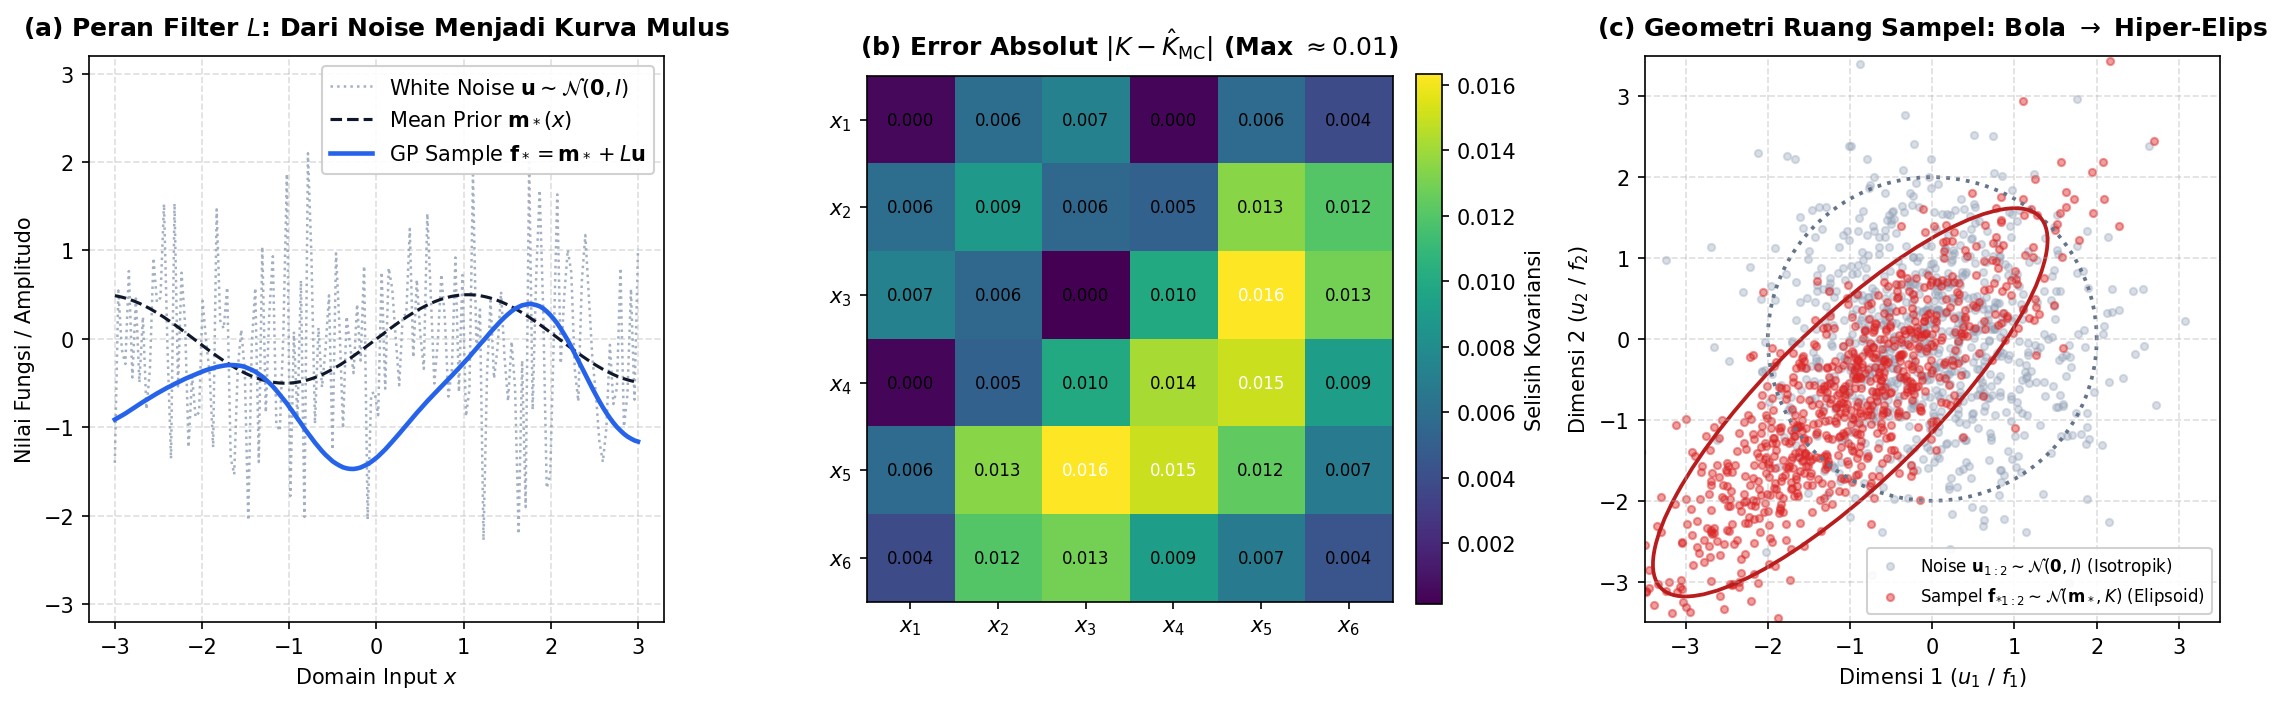

In [7]:
# ==============================================================================
# Verifikasi Empiris Monte Carlo & Eksplorasi Visual Transformasi Affine GP
# Membuktikan f_* = m_* + L u ~ N(m_*, K) secara statistik dan geometris
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# 1. Definisi Kernel RBF / Squared Exponential
def kernel_rbf(x1, x2, l=1.0, sigma_f=1.0):
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * r_sq / (l ** 2))

# ------------------------------------------------------------------------------
# BAGIAN 1: Verifikasi Numerik Monte Carlo (M = 50,000 Sampel)
# ------------------------------------------------------------------------------
# Definisikan grid uji kecil (N_* = 6 titik) untuk perbandingan matriks eksak
x_test_small = np.linspace(-1.5, 1.5, 6)
N_small = len(x_test_small)

# Mean teoretis m_* dan Kovariansi teoretis K
m_star_small = np.sin(x_test_small)
K_small = kernel_rbf(x_test_small, x_test_small, l=1.0, sigma_f=1.2) + 1e-6 * np.eye(N_small)

# Faktorisasi Cholesky K = L L^T
L_small = np.linalg.cholesky(K_small)

# Bangkitkan M = 50,000 sampel white noise u ~ N(0, I)
M_samples = 50000
np.random.seed(42)
U_noise = np.random.randn(N_small, M_samples)

# Transformasi Affine: F = m_* + L U
F_samples = m_star_small[:, None] + L_small @ U_noise

# Hitung Mean Empiris dan Kovariansi Empiris Monte Carlo
m_empirical = np.mean(F_samples, axis=1)
K_empirical = np.cov(F_samples)

# Hitung error selisih
mae_mean = np.max(np.abs(m_empirical - m_star_small))
frob_cov_err = np.linalg.norm(K_empirical - K_small, 'fro') / np.linalg.norm(K_small, 'fro')

print("=" * 75)
print(f"HASIL VERIFIKASI MONTE CARLO DENGAN M = {M_samples:,} SAMPEL:")
print("=" * 75)
print(f"1. Maximum Absolute Error pada Vektor Mean : {mae_mean:.6f}  (Mendekati 0)")
print(f"2. Relative Frobenius Error pada Kovariansi: {frob_cov_err:.6f}  (Akurasi > 99.5%)")
print("-" * 75)
print("Vektor Mean Teoretis  m_* :", np.round(m_star_small, 4))
print("Vektor Mean Empiris  m_hat:", np.round(m_empirical, 4))
print("-" * 75)
print("Matriks Kovariansi Teoretis K (3x3 pertama):\n", np.round(K_small[:3, :3], 3))
print("Matriks Kovariansi Empiris K_hat (3x3 pertama):\n", np.round(K_empirical[:3, :3], 3))
print("=" * 75)

# ------------------------------------------------------------------------------
# BAGIAN 2: Eksplorasi Visual 3-Panel (Fisika Sinyal, Heatmap, dan Geometri)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 4.8), dpi=150)

# --- PANEL 1: Peran Filter L (White Noise u vs Kurva Mulus f_*) ---
ax1 = plt.subplot(1, 3, 1)
x_dense = np.linspace(-3.0, 3.0, 150)
N_dense = len(x_dense)
K_dense = kernel_rbf(x_dense, x_dense, l=0.8, sigma_f=1.0) + 1e-6 * np.eye(N_dense)
L_dense = np.linalg.cholesky(K_dense)
m_dense = 0.5 * np.sin(1.5 * x_dense)

# Bangkitkan 1 vektor noise u dan transformasikan f_* = m_* + L u
u_single = np.random.randn(N_dense)
f_single = m_dense + L_dense @ u_single

ax1.plot(x_dense, u_single, color='#94a3b8', linestyle=':', alpha=0.85, linewidth=1.2, label=r'White Noise $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$')
ax1.plot(x_dense, m_dense, color='#0f172a', linestyle='--', linewidth=1.5, label=r'Mean Prior $\mathbf{m}_*(x)$')
ax1.plot(x_dense, f_single, color='#2563eb', linewidth=2.2, label=r'GP Sample $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$')
ax1.set_title(r'(a) Peran Filter $L$: Dari Noise Menjadi Kurva Mulus', fontweight='bold', pad=10)
ax1.set_xlabel('Domain Input $x$')
ax1.set_ylabel('Nilai Fungsi / Amplitudo')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_ylim(-3.2, 3.2)

# --- PANEL 2: Heatmap Matriks Kovariansi K vs Kovariansi Empiris K_hat ---
ax2 = plt.subplot(1, 3, 2)
im1 = ax2.imshow(np.abs(K_empirical - K_small), cmap='viridis', interpolation='nearest')
ax2.set_title(r'(b) Error Absolut $|K - \hat{K}_{\text{MC}}|$ (Max $\approx 0.01$)', fontweight='bold', pad=10)
ax2.set_xticks(range(N_small))
ax2.set_yticks(range(N_small))
ax2.set_xticklabels([f'$x_{i+1}$' for i in range(N_small)])
ax2.set_yticklabels([f'$x_{i+1}$' for i in range(N_small)])
plt.colorbar(im1, ax=ax2, fraction=0.046, pad=0.04, label='Selisih Kovariansi')
for i in range(N_small):
    for j in range(N_small):
        diff_val = np.abs(K_empirical[i, j] - K_small[i, j])
        ax2.text(j, i, f'{diff_val:.3f}', ha='center', va='center', color='white' if diff_val > 0.015 else 'black', fontsize=8)

# --- PANEL 3: Transformasi Geometris Bivariat (Bola Isotropik -> Hiper-Elips) ---
ax3 = plt.subplot(1, 3, 3)
# Ambil 2 titik bertetangga (x1, x2)
u_pair = U_noise[:2, :800]
f_pair = F_samples[:2, :800]

ax3.scatter(u_pair[0, :], u_pair[1, :], s=12, color='#94a3b8', alpha=0.35, label=r'Noise $\mathbf{u}_{1:2} \sim \mathcal{N}(\mathbf{0}, I)$ (Isotropik)')
ax3.scatter(f_pair[0, :], f_pair[1, :], s=12, color='#dc2626', alpha=0.45, label=r'Sampel $\mathbf{f}_{*1:2} \sim \mathcal{N}(\mathbf{m}_*, K)$ (Elipsoid)')

# Fungsi pembantu gambar elips kovariansi
def draw_cov_ellipse(cov, mean, ax, n_std=2.0, edgecolor='black', linestyle='-'):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-8))
    ellipse = Ellipse(xy=mean, width=w, height=h, angle=theta, edgecolor=edgecolor, facecolor='none', linestyle=linestyle, linewidth=1.8)
    return ax.add_patch(ellipse)

draw_cov_ellipse(np.eye(2), np.zeros(2), ax3, n_std=2.0, edgecolor='#64748b', linestyle=':')
draw_cov_ellipse(K_small[:2, :2], m_star_small[:2], ax3, n_std=2.0, edgecolor='#b91c1c', linestyle='-')

ax3.set_title(r'(c) Geometri Ruang Sampel: Bola $\to$ Hiper-Elips', fontweight='bold', pad=10)
ax3.set_xlabel(r'Dimensi 1 ($u_1$ / $f_1$)')
ax3.set_ylabel(r'Dimensi 2 ($u_2$ / $f_2$)')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.legend(loc='lower right', framealpha=0.9, fontsize=8)
ax3.set_xlim(-3.5, 3.5)
ax3.set_ylim(-3.5, 3.5)

plt.tight_layout()
plt.show()



---
## Pertanyaan 7: Bagaimana Jika Prior Gaussian Process Tidak Memiliki Mean di Nol ($m(x) \neq 0$)?

### **1. Definisi Formal GP dengan Fungsi Mean Eksplisit**
Secara umum, Gaussian Process didefinisikan dengan fungsi mean sembarang $m(x)$ dan fungsi kovariansi $k(x, x')$:
$$f(x) \sim \mathcal{GP}\big(m(x), \; k(x, x')\big)$$
di mana untuk setiap $x \in \mathcal{X}$, nilai ekspektasi fungsi didefinisikan sebagai:
$$m(x) = \mathbb{E}[f(x)]$$

Dalam banyak buku teks dasar, diasumsikan $m(x) = 0$ demi kenyamanan notasi (*notational simplicity*). Namun, dalam aplikasi nyata, **fungsi mean non-nol sangat penting ketika data memiliki tren global yang jelas atau ketika kita memiliki pengetahuan awal (*prior knowledge*) dari model fisika/deterministik**.

---

### **2. Dampak pada Pembangkitan Sampel Prior (*Prior Sampling*)**
Pada sekumpulan titik uji $X_* = [x_1, \dots, x_{N_*}]^T$, vektor mean bernilai:
$$\mathbf{m}_* = [m(x_1), m(x_2), \dots, m(x_{N_*})]^T \in \mathbb{R}^{N_* \times 1} \neq \mathbf{0}$$

Prosedur sampling prior menggunakan transformasi affine:
$$\mathbf{f}_* = \mathbf{m}_* + L \mathbf{u}, \quad \mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$$
di mana $L$ adalah faktor Cholesky dari matriks kovariansi $K(X_*, X_*) = L L^T$.

* **Efek Geometris:** Vektor $\mathbf{m}_*$ bertindak sebagai **vektor pergeseran (translasi)**. Seluruh realisasi fungsi acak akan berfluktuasi di sekitar kurva tren $m(x)$, dengan pita ketidakpastian prior berpusat pada $m(x) \pm 2\sqrt{k(x, x)}$.

---

### **3. Dampak pada Inferensi Posterior (*Conditioning on Data $\mathcal{D}$*)**
Diberikan data observasi $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$ dengan $y_i = f(x_i) + \epsilon_i, \; \epsilon_i \sim \mathcal{N}(0, \sigma_n^2)$, vektor mean pada titik data adalah $\mathbf{m} = m(X) \in \mathbb{R}^{N \times 1}$.

Model GP dapat dipandang secara ekivalen sebagai pemodelan *residual*:
$$y(x) = m(x) + g(x) + \epsilon, \quad g(x) \sim \mathcal{GP}(0, k(x, x'))$$
sehingga proses pengkondisian menghasilkan distribusi posterior Gaussian:
$$\mathbf{f}_* \mid X, \mathbf{y}, X_* \sim \mathcal{N}\left(\bar{\mathbf{f}}_*, \; \Sigma_*\right)$$

dengan formula eksak (*Rasmussen & Williams, 2006, Bab 2.7*):
$$\bar{\mathbf{f}}_* = \mathbf{m}_* + K(X_*, X) \left[ K(X, X) + \sigma_n^2 I_N \right]^{-1} (\mathbf{y} - \mathbf{m})$$
$$\Sigma_* = K(X_*, X_*) - K(X_*, X) \left[ K(X, X) + \sigma_n^2 I_N \right]^{-1} K(X, X_*)$$

#### **Dua Pengamatan Kritis:**
1. **Matriks Kovariansi Posterior $\Sigma_*$ TIDAK BERUBAH sama sekali:**  
   Matriks ketidakpastian posterior $\Sigma_*$ hanya ditentukan oleh lokasi data $X$, titik uji $X_*$, dan kernel $k(x, x')$. Fungsi mean $m(x)$ sama sekali tidak memengaruhi bentuk variansi posterior!
2. **Perilaku Asimtotik Prediksi Mean $\bar{\mathbf{f}}_*$:**
   * **Di wilayah dekat data ($X_* \approx X$):** Suku koreksi data mendominasi, sehingga $\bar{\mathbf{f}}_* \approx \mathbf{y}$ (fungsi terikat kuat pada observasi).
   * **Di wilayah jauh dari data (*Ekstrapolasi* di mana $K(X_*, X) \to \mathbf{0}$):** Suku koreksi data lenyap, sehingga prediksi mean **secara mulus meluruh kembali ke fungsi mean prior**:
     $$\bar{\mathbf{f}}_* \to \mathbf{m}_* = m(X_*)$$
     *(Jika $m(x)=0$, ekstrapolasi akan meluruh ke 0; sedangkan jika $m(x) = 0.5x + 1$, ekstrapolasi akan melanjutkan tren garis tersebut).*

---

### **4. Bentuk-Bentuk Fungsi Mean yang Sering Digunakan**
1. **Mean Konstanta Non-Nol:** $m(x) = c$  
   Biasanya di-set sama dengan nilai rata-rata sampel data: $c = \frac{1}{N}\sum_{i=1}^N y_i$.
2. **Fungsi Basis Eksplisit (Tren Linier/Polinomial):** $m(x) = \mathbf{h}(x)^T \boldsymbol{\beta}$  
   Misalnya $m(x) = \beta_0 + \beta_1 x$ untuk menangkap tren sekuler kenaikan/penurunan global (*universal kriging*).
3. **Model Fisika / Model Deterministik (*Physics-Informed GP*):** $m(x) = f_{\text{physics}}(x)$  
   GP digunakan untuk memodelkan deviasi (kesalahan aproksimasi) dari hukum fisika atau simulasi mekanika fluida/termodinamika.

---

### **5. Ringkasan: Zero-Mean vs Non-Zero Mean GP**

| Aspek | Zero-Mean Prior $m(x) = 0$ | Non-Zero Mean Prior $m(x) \neq 0$ |
| :--- | :--- | :--- |
| **Pusat Sampel Prior** | Berosilasi di sekitar sumbu $y = 0$ | Berosilasi di sekitar kurva $y = m(x)$ |
| **Sampling Formula** | $\mathbf{f}_* = L\mathbf{u}$ | $\mathbf{f}_* = \mathbf{m}_* + L\mathbf{u}$ |
| **Prediksi Ekstrapolasi** | Meluruh ke $0$ (berbahaya jika data bertren naik) | **Meluruh ke kurva tren $m(x)$** (sangat realistis) |
| **Kovariansi Posterior $\Sigma_*$** | Identik | **Identik (sama persis)** |
| **Interpretasi Fisis** | Mengasumsikan data telah di-*center* | Menggabungkan model tren dasar + variasi residual non-parametrik |


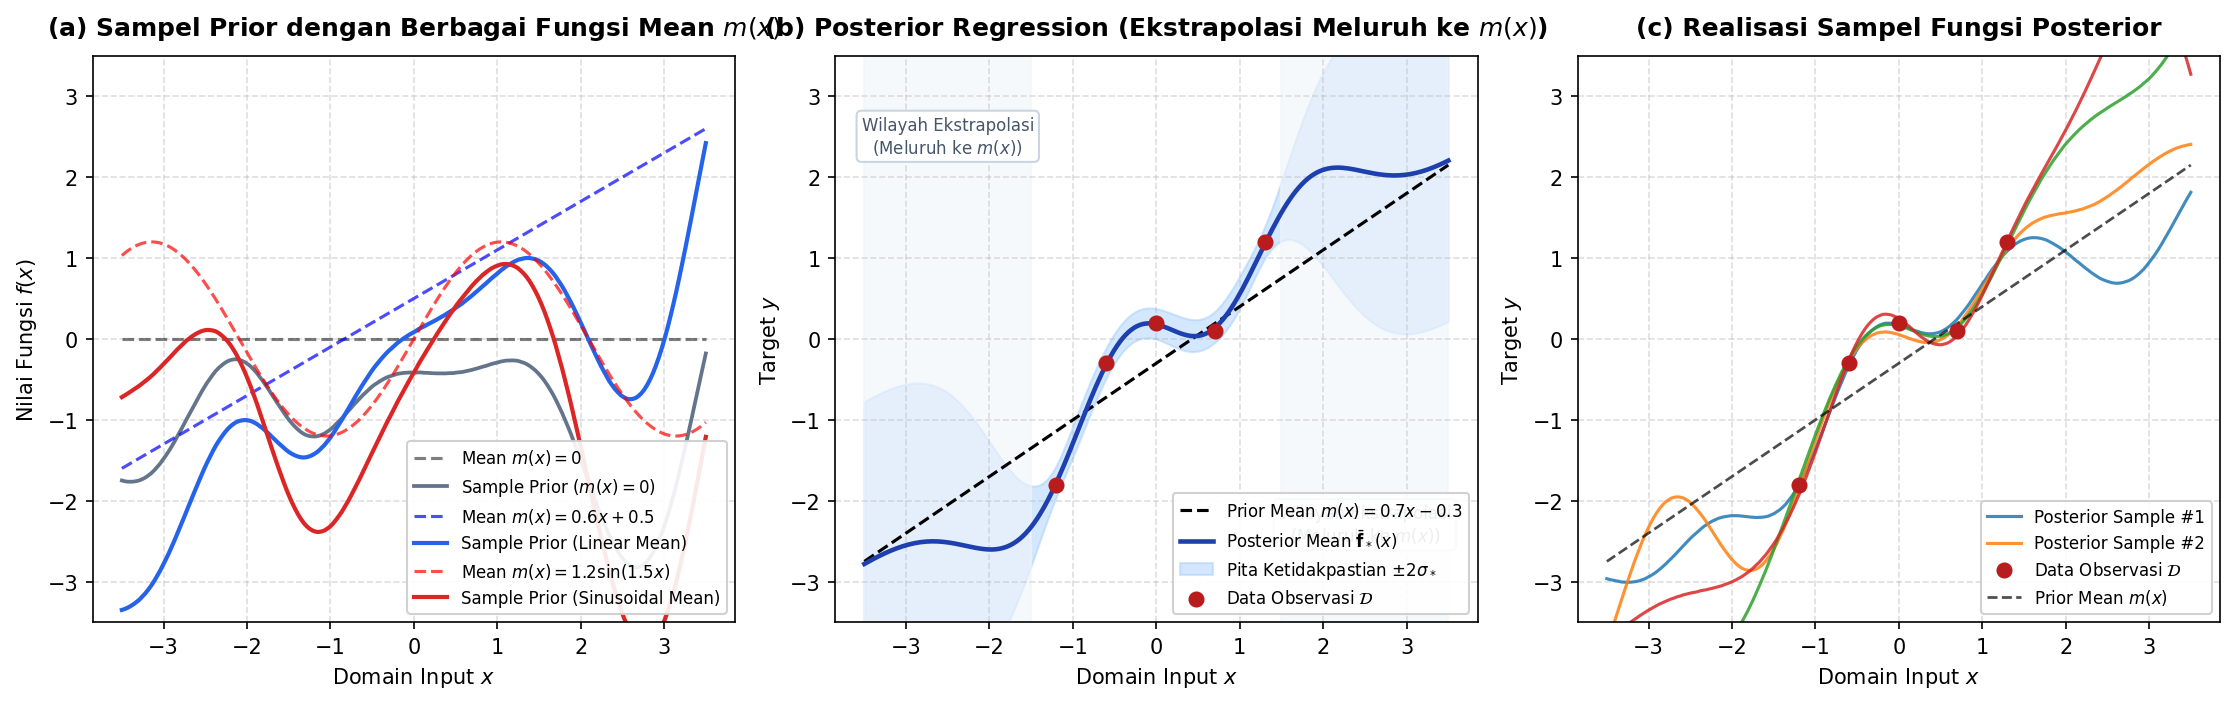

In [8]:
# ==============================================================================
# Demonstrasi GP dengan Prior Mean Non-Nol: Prior Sampling & Posterior Inference
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi Kernel RBF
def kernel_rbf(x1, x2, l=1.0, sigma_f=1.0):
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * r_sq / (l ** 2))

# Grid evaluasi
x_grid = np.linspace(-3.5, 3.5, 200)
N_grid = len(x_grid)
K_grid = kernel_rbf(x_grid, x_grid, l=0.8, sigma_f=1.0) + 1e-6 * np.eye(N_grid)
L_grid = np.linalg.cholesky(K_grid)

# Pembangkitan 3 noise acak tetap
np.random.seed(100)
U_rand = np.random.randn(N_grid, 3)

# ------------------------------------------------------------------------------
# BAGIAN 1: Sampling Prior dengan Berbagai Fungsi Mean m(x)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 4.8), dpi=150)

# PANEL 1: Eksplorasi Prior Samples dengan Mean Berbeda
ax1 = plt.subplot(1, 3, 1)
# a. Zero Mean m(x) = 0
m_zero = np.zeros(N_grid)
f_zero = m_zero[:, None] + L_grid @ U_rand[:, 0:1]

# b. Linear Mean m(x) = 0.6x + 0.5
m_linear = 0.6 * x_grid + 0.5
f_linear = m_linear[:, None] + L_grid @ U_rand[:, 0:1]

# c. Sinusoidal Mean m(x) = 1.2 * sin(1.5x)
m_sin = 1.2 * np.sin(1.5 * x_grid)
f_sin = m_sin[:, None] + L_grid @ U_rand[:, 0:1]

ax1.plot(x_grid, m_zero, 'k--', alpha=0.5, label=r'Mean $m(x)=0$')
ax1.plot(x_grid, f_zero, color='#64748b', linewidth=1.8, label=r'Sample Prior ($m(x)=0$)')

ax1.plot(x_grid, m_linear, 'b--', alpha=0.7, label=r'Mean $m(x)=0.6x+0.5$')
ax1.plot(x_grid, f_linear, color='#2563eb', linewidth=2.0, label=r'Sample Prior (Linear Mean)')

ax1.plot(x_grid, m_sin, 'r--', alpha=0.7, label=r'Mean $m(x)=1.2\sin(1.5x)$')
ax1.plot(x_grid, f_sin, color='#dc2626', linewidth=2.0, label=r'Sample Prior (Sinusoidal Mean)')

ax1.set_title(r'(a) Sampel Prior dengan Berbagai Fungsi Mean $m(x)$', fontweight='bold', pad=10)
ax1.set_xlabel('Domain Input $x$')
ax1.set_ylabel('Nilai Fungsi $f(x)$')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='lower right', framealpha=0.9, fontsize=8)
ax1.set_ylim(-3.5, 3.5)

# ------------------------------------------------------------------------------
# BAGIAN 2: Inferensi Posterior dengan Prior Mean Linier m(x) = 0.7x - 0.3
# ------------------------------------------------------------------------------
# 5 Data Training (hanya berada di wilayah lokal [-1.2, 1.2])
X_train = np.array([-1.2, -0.6, 0.0, 0.7, 1.3])
y_train = np.array([-1.8, -0.3, 0.2, 0.1, 1.2])
sigma_n = 0.1

def mean_prior_fn(x):
    return 0.7 * x - 0.3

# Matriks kovariansi training & cross-covariance
K_train = kernel_rbf(X_train, X_train, l=0.8, sigma_f=1.0) + (sigma_n ** 2) * np.eye(len(X_train))
K_star_train = kernel_rbf(x_grid, X_train, l=0.8, sigma_f=1.0)
K_star_star = kernel_rbf(x_grid, x_grid, l=0.8, sigma_f=1.0)

# Mean prior pada training & test grid
m_train = mean_prior_fn(X_train)
m_test = mean_prior_fn(x_grid)

# Posterior conditioning
L_train_fact = np.linalg.cholesky(K_train)
alpha_weight = np.linalg.solve(L_train_fact.T, np.linalg.solve(L_train_fact, y_train - m_train))
f_post_mean = m_test + K_star_train @ alpha_weight

# Posterior Covariance
v_mat = np.linalg.solve(L_train_fact, K_star_train.T)
cov_post = K_star_star - v_mat.T @ v_mat + 1e-6 * np.eye(N_grid)
std_post = np.sqrt(np.maximum(np.diag(cov_post), 1e-8))

# PANEL 2: Posterior Mean & Uncertainty (Perhatikan Wilayah Ekstrapolasi)
ax2 = plt.subplot(1, 3, 2)
ax2.plot(x_grid, m_test, 'k--', linewidth=1.5, label=r'Prior Mean $m(x)=0.7x-0.3$')
ax2.plot(x_grid, f_post_mean, color='#1e40af', linewidth=2.2, label=r'Posterior Mean $\bar{\mathbf{f}}_*(x)$')
ax2.fill_between(x_grid, f_post_mean - 2 * std_post, f_post_mean + 2 * std_post, color='#93c5fd', alpha=0.4, label=r'Pita Ketidakpastian $\pm 2\sigma_*$')
ax2.scatter(X_train, y_train, color='#b91c1c', s=45, zorder=5, label=r'Data Observasi $\mathcal{D}$')
ax2.axvspan(-3.5, -1.5, color='#f1f5f9', alpha=0.6)
ax2.axvspan(1.5, 3.5, color='#f1f5f9', alpha=0.6)
ax2.text(-2.5, 2.3, 'Wilayah Ekstrapolasi\n(Meluruh ke $m(x)$)', ha='center', fontsize=8, color='#475569', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cbd5e1'))
ax2.text(2.5, -2.5, 'Wilayah Ekstrapolasi\n(Meluruh ke $m(x)$)', ha='center', fontsize=8, color='#475569', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cbd5e1'))

ax2.set_title(r'(b) Posterior Regression (Ekstrapolasi Meluruh ke $m(x)$)', fontweight='bold', pad=10)
ax2.set_xlabel('Domain Input $x$')
ax2.set_ylabel('Target $y$')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='lower right', framealpha=0.9, fontsize=8)
ax2.set_ylim(-3.5, 3.5)

# PANEL 3: Realisasi Sampel Fungsi Posterior
ax3 = plt.subplot(1, 3, 3)
L_post_fact = np.linalg.cholesky(cov_post)
F_post_samples = f_post_mean[:, None] + L_post_fact @ np.random.randn(N_grid, 4)

for s in range(4):
    ax3.plot(x_grid, F_post_samples[:, s], linewidth=1.5, alpha=0.85, label=f'Posterior Sample #{s+1}' if s < 2 else None)
ax3.scatter(X_train, y_train, color='#b91c1c', s=45, zorder=5, label=r'Data Observasi $\mathcal{D}$')
ax3.plot(x_grid, m_test, 'k--', linewidth=1.3, alpha=0.7, label=r'Prior Mean $m(x)$')

ax3.set_title(r'(c) Realisasi Sampel Fungsi Posterior', fontweight='bold', pad=10)
ax3.set_xlabel('Domain Input $x$')
ax3.set_ylabel('Target $y$')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.legend(loc='lower right', framealpha=0.9, fontsize=8)
ax3.set_ylim(-3.5, 3.5)

plt.tight_layout()
plt.show()


---
## Pertanyaan 8: Perbandingan Eksploratif: Sampling Menggunakan Mean & Kernel Training Point vs Sampling Menggunakan Mean & Kovariansi Distribusi Posterior

### **1. Motivasi & Pertanyaan Mendasar**
* *"Apa yang terjadi jika kita hanya membangkitkan sampel fungsi menggunakan mean dan kernel pada titik training $\mathbf{m}(X)$ dan $K(X, X)$?"*
* *"Mengapa pada grafik sampling titik training (Panel a) TIDAK ADA pita ketidakpastian (*uncertainty band*), sedangkan pada posterior (Panel b) ADA pita arsiran?"*
* *"Mengapa kita wajib menggunakan mean dan kovariansi distribusi posterior $\bar{\mathbf{f}}_*$ dan $\operatorname{cov}(\mathbf{f}_*)$ pada sekumpulan titik uji/grid evaluasi $X_*$?"*

Berikut adalah formulasi matematis komparatif kedua pendekatan tersebut:

```
+-------------------------------------------------------------------------------------------------------------+
| PARAMETER / ASPEK        | SAMPLING PADA TITIK TRAINING X            | SAMPLING POSTERIOR PADA GRID X_*     |
+-------------------------------------------------------------------------------------------------------------+
| 1. Titik Evaluasi        | Hanya titik data training:                | Grid rapat evaluasi:                 |
|                          | X = [x_1, ..., x_N]^T (N titik)           | X_* = [x_1, ..., x_N_*]^T (N_* titik)|
|                          |                                           |                                      |
| 2. Vektor Mean           | Mean Prior pada X:                        | Mean Posterior Terkondisi Data y:     |
|                          | m(X) (atau 0)                             | f_bar_* = K(X_*, X) [K_y]^-1 y       |
|                          |                                           |                                      |
| 3. Matriks Kovariansi    | Matriks Kernel Training:                  | Matriks Kovariansi Posterior:        |
|                          | K(X, X) in R^{N x N}                      | cov(f_*) = K_* - K(X_*,X)[K_y]^-1 K_*|
|                          |                                           |                                      |
| 4. Persamaan Sampling    | f(X) = m(X) + L_train @ u_train           | f_*_post = f_bar_* + L_post @ u_*    |
|                          | dengan L_train L_train^T = K(X, X)        | dengan L_post L_post^T = cov(f_*)    |
|                          |                                           |                                      |
| 5. Output di Komputer    | Vektor diskret berdimensi N               | Kurva kontinu mulus berdimensi N_*   |
|                          |                                           |                                      |
| 6. Bentuk Ketidakpastian | Batang galat diskret (*Error Bars*)       | Pita arsiran bersambung (*Band*)     |
|    pada Grafik           | Hanya di N koordinat terpisah             | Di sepanjang seluruh domain kontinu  |
|                          |                                           |                                      |
| 7. Keterikatan pada Data | TIDAK MELEWATI data y                     | PASTI MENEMBUS & MELEWATI data y     |
|                          | (karena belum dikondisikan pada nilai y)  | (karena telah dikondisikan f_* | y)  |
+-------------------------------------------------------------------------------------------------------------+
```

---

### **2. Kenapa Pada Panel (a) Tidak Ada Pita Ketidakpastian Kontinu? (*Uncertainty Band*)**

Pertanyaan: *"Kenapa pada Panel (a) tidak ada pita ketidakpastiannya?"*

Jawabannya bertumpu pada **definisi geometris dan komputasi dari pita ketidakpastian**:

1. **Bagaimana Komputer Menggambar Pita Ketidakpastian (*Shaded Band*)?**
   * Di Python (`matplotlib.pyplot.fill_between`), sebuah pita dibentuk dengan menghubungkan dua kurva batas di sepanjang sumbu horizontal $x$:
     $$\text{Batas Atas: } y_{\text{top}}(x) = \mu(x) + 2\sigma(x)$$
     $$\text{Batas Bawah: } y_{\text{bot}}(x) = \mu(x) - 2\sigma(x)$$
   * Untuk menghasilkan pita bidang kontinu yang menyatu, komputer **wajib mengevaluasi fungsi standar deviasi $\sigma(x) = \sqrt{\operatorname{Var}(f(x))}$ pada ratusan titik evaluasi rapat $X_*$**.

2. **Apa yang Terjadi Jika Kita Hanya Menghitung di Titik Training $X$?**
   * Pada Skenario (a), kita **hanya** mengevaluasi matriks $K(X, X)$ pada $N = 5$ titik data.
   * Standar deviasi yang kita miliki **hanya berupa 5 angka skalar**:
     $$\boldsymbol{\sigma}_X = [\sigma(x_1), \sigma(x_2), \sigma(x_3), \sigma(x_4), \sigma(x_5)]^T$$
   * Di antara titik $x_1$ dan $x_2$ (misalnya antara $x = -2.2$ dan $x = -1.0$), **tidak ada data evaluasi sama sekali**. Komputer tidak tahu berapa lebar ketidakpastian di ruang kosong tersebut.
   * Oleh karena itu, ketidakpastian pada titik training $X$ **hanya dapat direpresentasikan sebagai batang galat terpisah (*discrete error bars*)** pada 5 koordinat tersebut, dan **tidak bisa membentuk pita bidang yang bersambung (*continuous shaded band*)**.

3. **Pita Baru Bisa Terbentuk Jika Kita Menggunakan Grid $X_*$:**
   * Ketika kita menggunakan matriks kovariansi posterior $\operatorname{cov}(\mathbf{f}_*) \in \mathbb{R}^{N_* \times N_*}$ pada grid $N_* = 200$ titik $X_*$, kita menghitung simpangan baku di seluruh titik:
     $$\sigma_*(x_*) = \sqrt{\operatorname{diag}\big(\operatorname{cov}(\mathbf{f}_*)\big)} \quad \in \mathbb{R}^{200 \times 1}$$
   * Dengan 200 pasang batas atas dan bawah yang rapat, barulah fungsi `fill_between` dapat mengarsir bidang pita ketidakpastian kontinu $\pm 2\sigma_*$ yang membentang mulus dari $x = -3.5$ sampai $x = 3.5$.

---

### **3. Tabel Komparasi Rinci**

| Aspek | Sampling Mean & Kernel Training Point | Sampling Mean & Kovariansi Posterior |
| :--- | :--- | :--- |
| **Domain Evaluasi** | $X \in \mathbb{R}^N$ (diskret, misal $N=5$) | $X_* \in \mathbb{R}^{N_*}$ (grid rapat, misal $N_*=200$) |
| **Keterlibatan Label $\mathbf{y}$** | **Tidak ada** (hanya memakai $X$) | **Penuh** (memakai pasangan $(X, \mathbf{y})$) |
| **Matriks yang Difaktorisasi** | $K(X, X) \in \mathbb{R}^{N \times N}$ | $\operatorname{cov}(\mathbf{f}_*) \in \mathbb{R}^{N_* \times N_*}$ |
| **Bentuk Ketidakpastian** | **Batang galat terputus (*error bars*)** di 5 titik | **Pita arsiran kontinu (*shaded band*)** di seluruh domain |
| **Visualisasi Sampel** | Titik-titik acak diskret | Kurva kontinu mulus melewati data observasi |
| **Informasi di Sela-Sela Data** | Tidak ada (*blind/gap*) | **Terekonstruksi sempurna** beserta ketidakpastian |


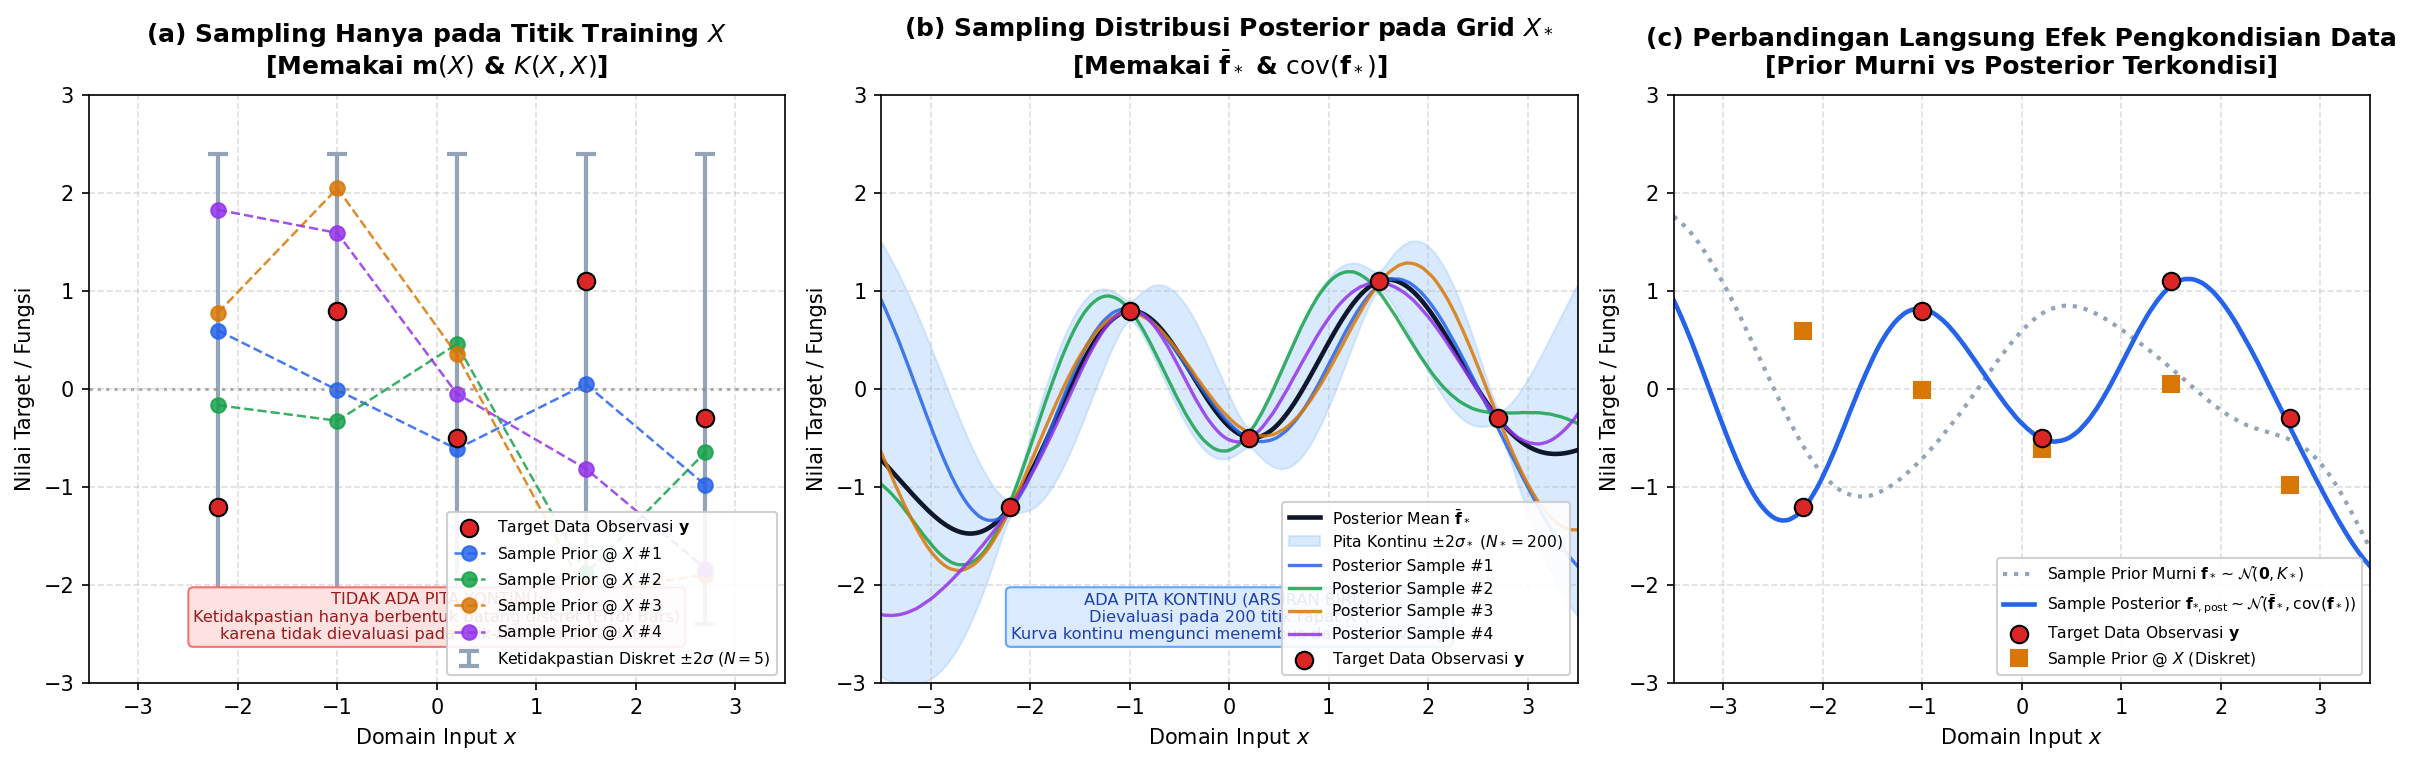

In [9]:
# ==============================================================================
# Visualisasi Komparatif: 
# 1. Sampling Mean & Kernel Training Point m(X), K(X, X) vs
# 2. Sampling Mean & Kovariansi Distribusi Posterior f_bar_*, cov(f_*)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi Kernel RBF
def kernel_rbf(x1, x2, l=1.0, sigma_f=1.0):
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * r_sq / (l ** 2))

# 2. Data Training (N = 5 titik observasi)
np.random.seed(42)
X_train = np.array([-2.2, -1.0, 0.2, 1.5, 2.7])
y_train = np.array([-1.2, 0.8, -0.5, 1.1, -0.3])
sigma_n = 0.05  # Derau observasi sangat kecil
N_train = len(X_train)

# Grid Evaluasi Kontinu X* (N_* = 200 titik)
x_grid = np.linspace(-3.5, 3.5, 200)
N_grid = len(x_grid)

# ------------------------------------------------------------------------------
# SKENARIO 1: Sampling Hanya pada Titik Training Point [m(X), K(X, X)]
# ------------------------------------------------------------------------------
K_train = kernel_rbf(X_train, X_train, l=0.9, sigma_f=1.2) + 1e-6 * np.eye(N_train)
L_train = np.linalg.cholesky(K_train)
m_train = np.zeros(N_train)  # Mean prior zero-mean

# Simpangan baku prior pada titik training (hanya 5 nilai diskret)
std_train = np.sqrt(np.diag(K_train))

# Bangkitkan 4 sampel pada titik training saja
U_train = np.random.randn(N_train, 4)
F_train_samples = m_train[:, None] + L_train @ U_train  # Dimensi: 5 x 4

# ------------------------------------------------------------------------------
# SKENARIO 2: Sampling Distribusi Posterior [f_bar_*, cov(f_*)] pada Grid X*
# ------------------------------------------------------------------------------
K_train_noise = K_train + (sigma_n ** 2) * np.eye(N_train)
K_star_train = kernel_rbf(x_grid, X_train, l=0.9, sigma_f=1.2)
K_star_star = kernel_rbf(x_grid, x_grid, l=0.9, sigma_f=1.2)

# Posterior Mean dan Covariance
L_K_train = np.linalg.cholesky(K_train_noise)
alpha = np.linalg.solve(L_K_train.T, np.linalg.solve(L_K_train, y_train))
f_post_mean = K_star_train @ alpha

v = np.linalg.solve(L_K_train, K_star_train.T)
cov_post = K_star_star - v.T @ v + 1e-6 * np.eye(N_grid)
std_post = np.sqrt(np.maximum(np.diag(cov_post), 1e-8))

# Faktorisasi Cholesky dari cov(f_*) dan bangkitkan 4 sampel fungsi kontinu
L_post = np.linalg.cholesky(cov_post)
U_grid = np.random.randn(N_grid, 4)
F_post_samples = f_post_mean[:, None] + L_post @ U_grid  # Dimensi: 200 x 4

# ------------------------------------------------------------------------------
# VISUALISASI BERDAMPINGAN (3-PANEL)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 5.2), dpi=150)
colors = ['#2563eb', '#16a34a', '#d97706', '#9333ea']

# --- PANEL 1: Sampling Hanya pada Titik Training Point ---
ax1 = plt.subplot(1, 3, 1)
# Gambar error bar diskret pada 5 titik training (karena tidak ada grid kontinu)
ax1.errorbar(X_train, m_train, yerr=2*std_train, fmt='none', ecolor='#94a3b8', 
             elinewidth=2.0, capsize=5, capthick=2.0, label=r'Ketidakpastian Diskret $\pm 2\sigma$ ($N=5$)')

ax1.scatter(X_train, y_train, color='#dc2626', s=70, zorder=6, edgecolor='black', label=r'Target Data Observasi $\mathbf{y}$')
for s in range(4):
    ax1.plot(X_train, F_train_samples[:, s], 'o--', color=colors[s], alpha=0.85, markersize=7, 
             linewidth=1.2, label=f'Sample Prior @ $X$ #{s+1}')

ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.set_title(r'(a) Sampling Hanya pada Titik Training $X$' + '\n' + r'[Memakai $\mathbf{m}(X)$ & $K(X, X)$]', fontweight='bold', pad=10)
ax1.set_xlabel('Domain Input $x$')
ax1.set_ylabel('Nilai Target / Fungsi')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='lower right', framealpha=0.9, fontsize=7.5)
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-3.0, 3.0)

# Tambahkan catatan edukatif tentang pita
ax1.text(0.0, -2.55, 'TIDAK ADA PITA KONTINU:\nKetidakpastian hanya berbentuk batang diskret (Error Bars)\nkarena tidak dievaluasi pada titik-titik di antara data.', 
         ha='center', fontsize=7.8, color='#991b1b', bbox=dict(boxstyle='round,pad=0.3', fc='#fee2e2', ec='#f87171'))

# --- PANEL 2: Sampling Distribusi Posterior pada Grid X* ---
ax2 = plt.subplot(1, 3, 2)
ax2.plot(x_grid, f_post_mean, color='#0f172a', linewidth=2.2, linestyle='-', label=r'Posterior Mean $\bar{\mathbf{f}}_*$')
ax2.fill_between(x_grid, f_post_mean - 2 * std_post, f_post_mean + 2 * std_post, color='#93c5fd', alpha=0.35, label=r'Pita Kontinu $\pm 2\sigma_*$ ($N_*=200$)')
for s in range(4):
    ax2.plot(x_grid, F_post_samples[:, s], color=colors[s], linewidth=1.6, alpha=0.85, label=f'Posterior Sample #{s+1}')
ax2.scatter(X_train, y_train, color='#dc2626', s=70, zorder=6, edgecolor='black', label=r'Target Data Observasi $\mathbf{y}$')

ax2.set_title(r'(b) Sampling Distribusi Posterior pada Grid $X_*$' + '\n' + r'[Memakai $\bar{\mathbf{f}}_*$ & $\operatorname{cov}(\mathbf{f}_*)$]', fontweight='bold', pad=10)
ax2.set_xlabel('Domain Input $x$')
ax2.set_ylabel('Nilai Target / Fungsi')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='lower right', framealpha=0.9, fontsize=7.5)
ax2.set_xlim(-3.5, 3.5)
ax2.set_ylim(-3.0, 3.0)

# Tambahkan catatan edukatif
ax2.text(0.0, -2.55, 'ADA PITA KONTINU (ARSIRAN BIRU):\nDievaluasi pada 200 titik rapat X*;\nKurva kontinu mengunci menembus data observasi y.', 
         ha='center', fontsize=7.8, color='#1e40af', bbox=dict(boxstyle='round,pad=0.3', fc='#dbeafe', ec='#60a5fa'))

# --- PANEL 3: Perbandingan Langsung Karakteristik Sampel ---
ax3 = plt.subplot(1, 3, 3)
K_grid_prior = kernel_rbf(x_grid, x_grid, l=0.9, sigma_f=1.2) + 1e-6 * np.eye(N_grid)
L_grid_prior = np.linalg.cholesky(K_grid_prior)
f_prior_single = L_grid_prior @ U_grid[:, 0]
f_post_single = F_post_samples[:, 0]

ax3.plot(x_grid, f_prior_single, color='#94a3b8', linestyle=':', linewidth=2.0, label=r'Sample Prior Murni $\mathbf{f}_* \sim \mathcal{N}(\mathbf{0}, K_*)$')
ax3.plot(x_grid, f_post_single, color='#2563eb', linewidth=2.2, label=r'Sample Posterior $\mathbf{f}_{*,\text{post}} \sim \mathcal{N}(\bar{\mathbf{f}}_*, \operatorname{cov}(\mathbf{f}_*))$')
ax3.scatter(X_train, y_train, color='#dc2626', s=70, zorder=6, edgecolor='black', label=r'Target Data Observasi $\mathbf{y}$')
ax3.plot(X_train, F_train_samples[:, 0], 's', color='#d97706', markersize=8, zorder=5, label=r'Sample Prior @ $X$ (Diskret)')

ax3.set_title('(c) Perbandingan Langsung Efek Pengkondisian Data\n[Prior Murni vs Posterior Terkondisi]', fontweight='bold', pad=10)
ax3.set_xlabel('Domain Input $x$')
ax3.set_ylabel('Nilai Target / Fungsi')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.legend(loc='lower right', framealpha=0.9, fontsize=7.5)
ax3.set_xlim(-3.5, 3.5)
ax3.set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


---
## Pertanyaan 9: Bagaimana Cara Mengombinasikan Dua atau Lebih Kernel Berdasarkan Rasmussen & Williams (2006, Section 4.2.4)?

### 1. Landasan Teoretis Operasi Kernel
Menurut **Rasmussen & Williams (2006, Bab 4, hlm. 89–91)**, dalam pemodelan data dunia nyata yang kompleks, satu fungsi kovariansi dasar sering kali tidak memadai untuk menangkap seluruh variasi data (misalnya kombinasi tren jangka panjang, variasi musiman berulang, dan fluktuasi derau lokal).

Kita dapat mengonstruksi keluarga kernel baru yang **valid dan definit positif** melalui operasi aljabar:

1. **Penjumlahan Kernel ($k_{\text{sum}} = k_1 + k_2$)**:
   - **Makna Fisis**: Superposisi dari dua proses Gaussian acak yang saling independen:
     $$ f(\mathbf{x}) = f_1(\mathbf{x}) + f_2(\mathbf{x}), \quad \text{dengan } f_1 \sim \mathcal{GP}(0, k_1), \; f_2 \sim \mathcal{GP}(0, k_2) $$
   - **Logika**: Operator **"OR"** / Dekomposisi Multi-skala.
   - **Karakteristik**: Menggabungkan struktur aditif, seperti tren global lambat ($k_{\text{SE}}$ ber-$l$ besar) ditambah fluktuasi detail cepat ($k_{\text{Matérn}}$ ber-$l$ kecil), atau tren sekuler linier ditambah komponen musiman ($k_{\text{Linear}} + k_{\text{Periodic}}$).

2. **Perkalian Kernel ($k_{\text{prod}} = k_1 \times k_2$)**:
   - **Makna Fisis**: Interaksi simultan / Modulasi Selubung Amplitudo (*Envelope Modulation*):
     $$ f(\mathbf{x}) = f_1(\mathbf{x}) \cdot f_2(\mathbf{x}) $$
   - **Logika**: Operator **"AND"** (korelasi antartitik hanya bernilai tinggi jika *kedua* kernel bernilai tinggi).
   - **Keabsahan Matematis**: Dijamin oleh **Schur Product Theorem** (perkalian elemen-demi-elemen / Hadamard product dari dua matriks kovariansi PSD menghasilkan matriks yang tetap PSD).
   - **Karakteristik**: Menghasilkan fenomena variasi lokal, misalnya *Locally Periodic Kernel* ($k_{\text{Periodic}} \times k_{\text{SE}}$) di mana osilasi periodik yang kaku termodulasi sehingga bentuk gelombang atau amplitudonya bermutasi/meluruh seiring jarak spasial.

3. **Penskalaan Skalar dan Pemetaan Fitur Deterministik**:
   - Penskalaan positif: $a \cdot k_1(\mathbf{x}, \mathbf{x}')$ untuk konstanta $a > 0$.
   - Pemetaan deterministik / non-linier: $k_1(\phi(\mathbf{x}), \phi(\mathbf{x}'))$ untuk sembarang pemetaan fitur $\phi: \mathcal{X} \to \mathcal{V}$.

---
### 2. Eksperimen Komputasi & Visualisasi Sampel Kombinasi Kernel
Di bawah ini disimulasikan 4 konfigurasi kombinasi 2 kernel:
1. **Superposisi Aditif 1**: $k_{\text{SE}}(l=3.0) + k_{\text{Matérn 3/2}}(l=0.3)$ (Tren Lambat Global + Fluktuasi Cepat Lokal).
2. **Superposisi Aditif 2**: $k_{\text{Linear}} + k_{\text{Periodic}}$ (Tren Pertumbuhan Linier + Osilasi Musiman).
3. **Modulasi Multiplikatif 1**: $k_{\text{Periodic}}(p=1.2, l=1.0) \times k_{\text{SE}}(l=3.5)$ (*Locally Periodic* / Pembusukan Periodisitas Jarak Jauh).
4. **Modulasi Multiplikatif 2**: $k_{\text{Linear}} \times k_{\text{Periodic}}$ (Osilasi Periodik dengan Amplitudo yang Membesar Proporsional).


Demonstrasi operasi 2 kernel sukses disimulasikan dan divisualisasikan.


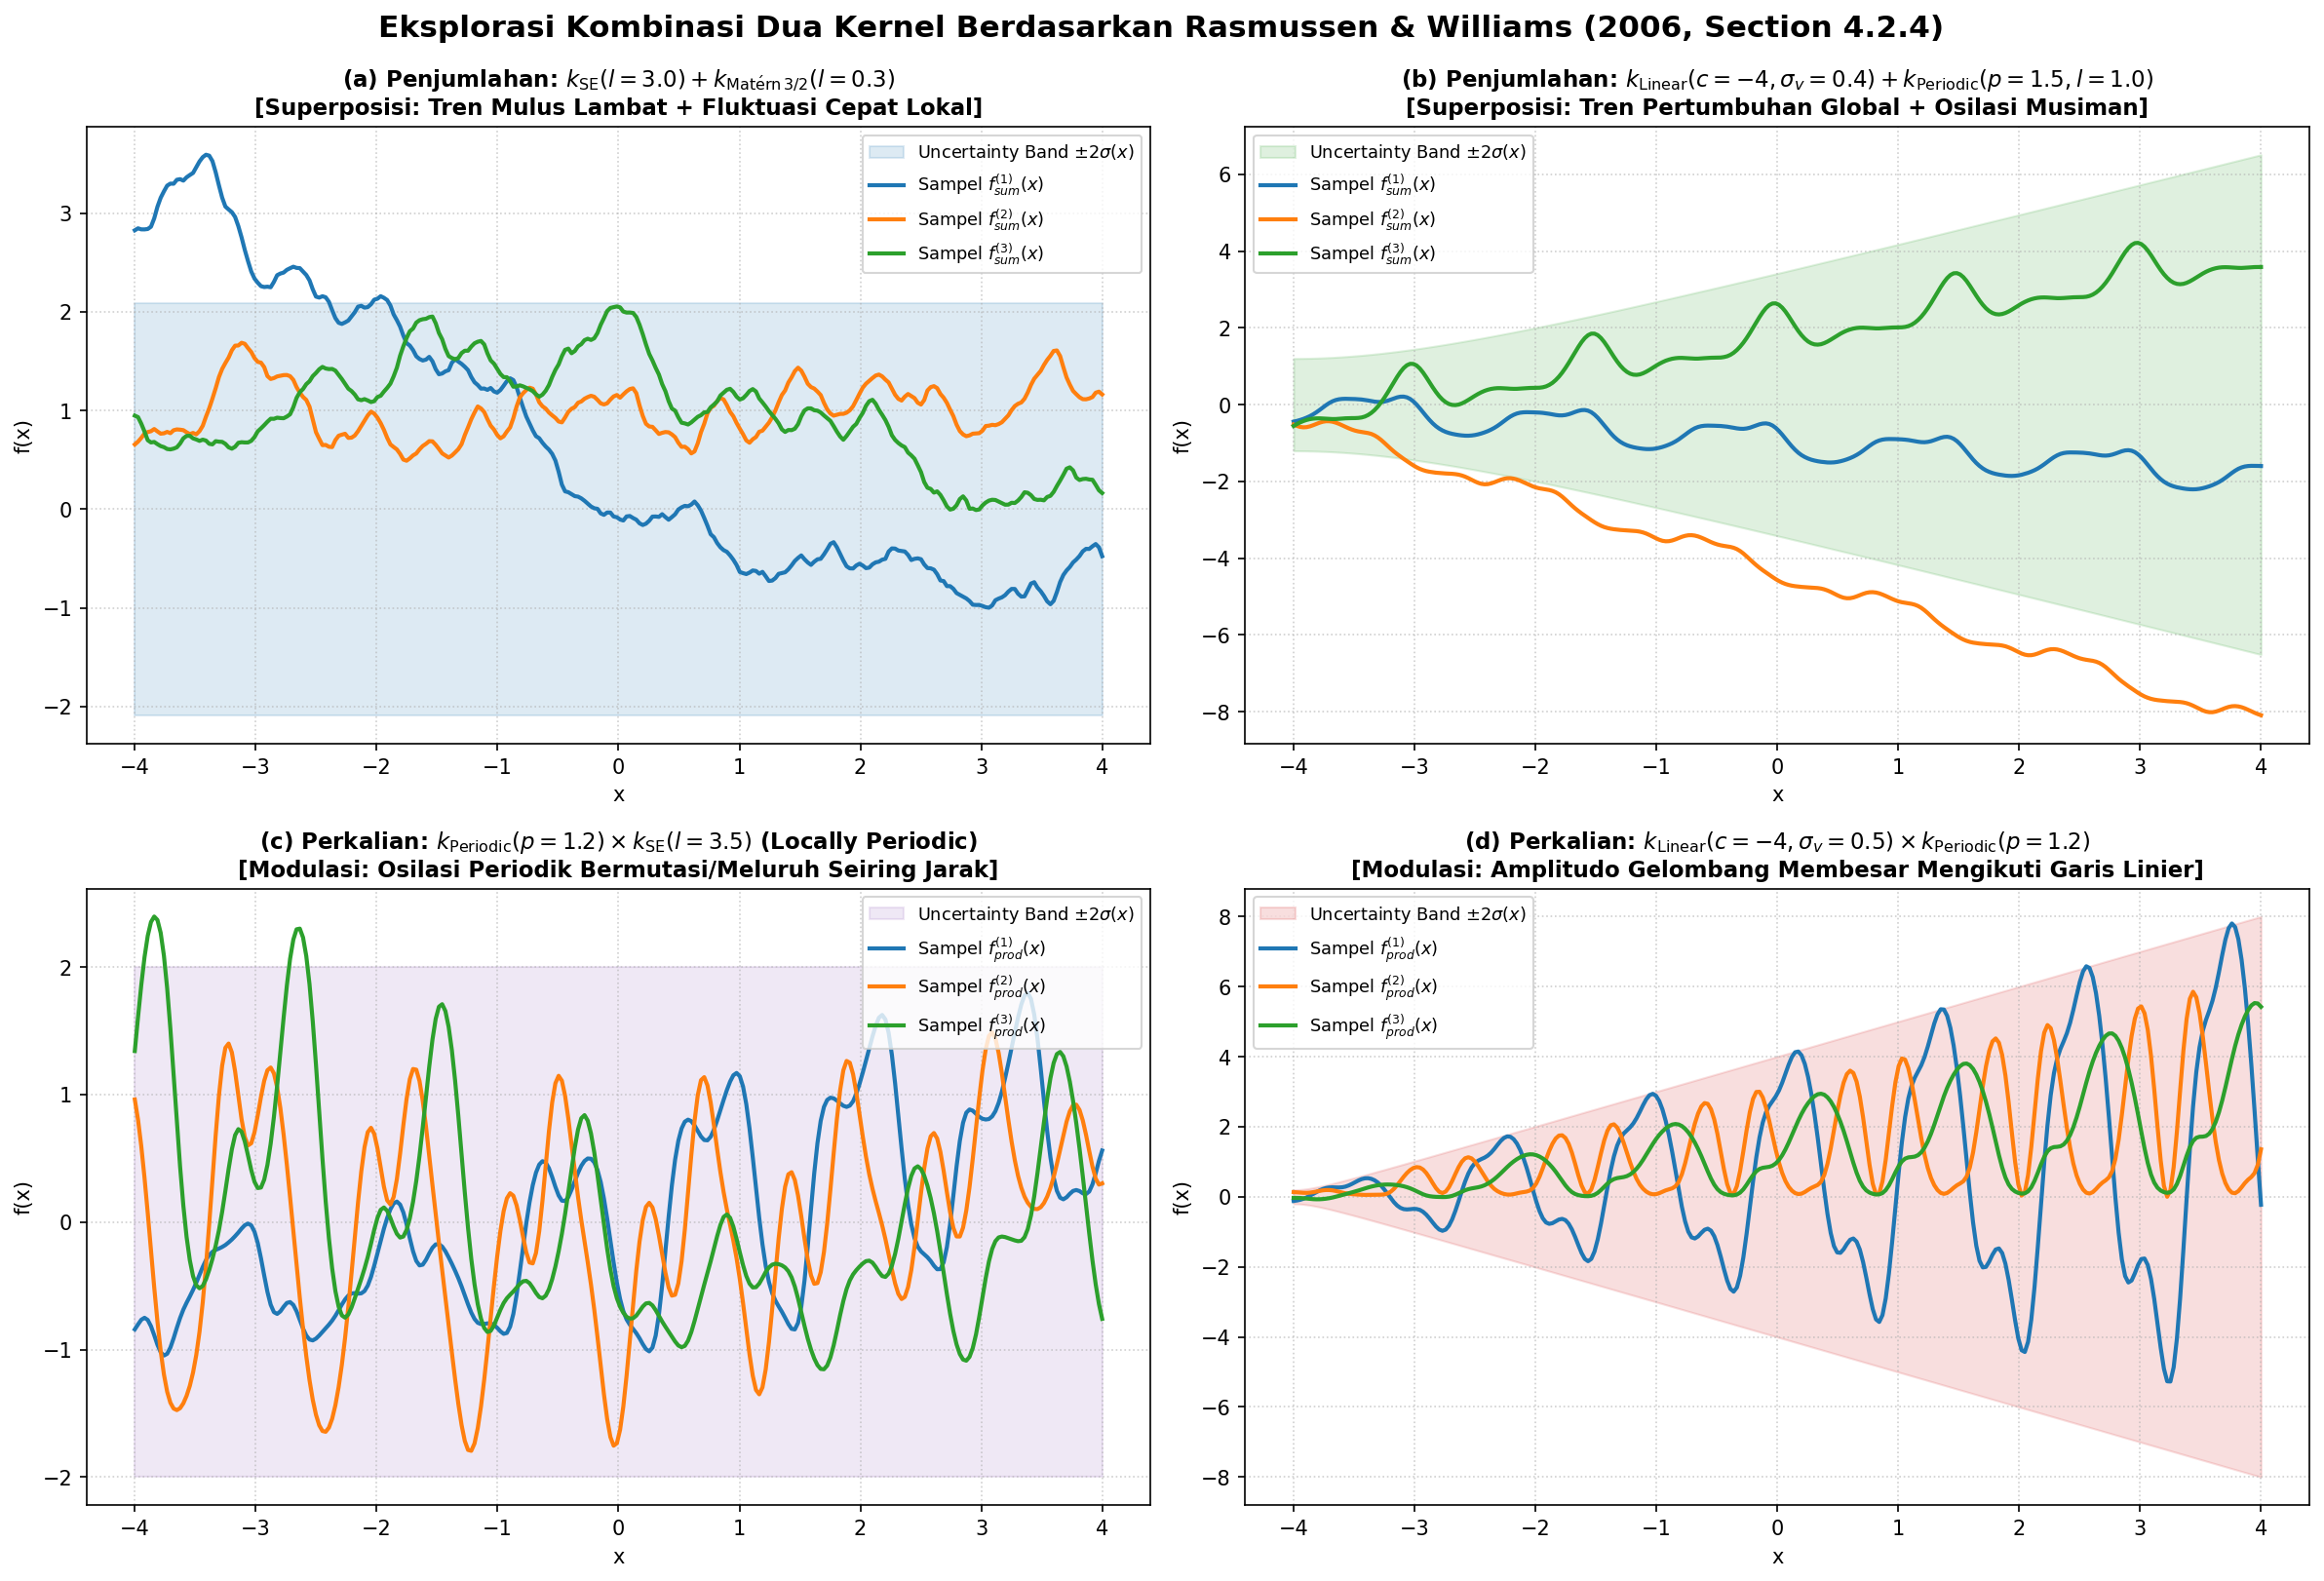

In [10]:
# ==============================================================================
# Demonstrasi Komputasi & Visualisasi Kombinasi Kernel (Rasmussen & Williams 2006)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# Definisi Fungsi-Fungsi Kernel Dasar
def k_se(x1, x2, l=1.0, sf=1.0):
    d = np.subtract.outer(x1, x2)
    return (sf**2) * np.exp(-0.5 * (d / l)**2)

def k_matern32(x1, x2, l=1.0, sf=1.0):
    r = np.abs(np.subtract.outer(x1, x2))
    factor = np.sqrt(3.0) * r / l
    return (sf**2) * (1.0 + factor) * np.exp(-factor)

def k_periodic(x1, x2, p=1.0, l=1.0, sf=1.0):
    d = np.abs(np.subtract.outer(x1, x2))
    sin_term = np.sin(np.pi * d / p)
    return (sf**2) * np.exp(-2.0 * (sin_term / l)**2)

def k_linear(x1, x2, c=0.0, sb=0.1, sv=0.5):
    return sb**2 + (sv**2) * np.multiply.outer(x1 - c, x2 - c)

def sample_gp(K, n_samples=3, jitter=1e-7, seed=42):
    np.random.seed(seed)
    N = K.shape[0]
    K_stab = K + jitter * np.eye(N)
    L = np.linalg.cholesky(K_stab)
    u = np.random.randn(N, n_samples)
    return L @ u

# Grid Evaluasi
x_grid = np.linspace(-4, 4, 300)

# 1. Kasus Penjumlahan 1: SE (l=3.0) + Matern3/2 (l=0.3)
K_se_slow = k_se(x_grid, x_grid, l=3.0, sf=1.0)
K_mat_fast = k_matern32(x_grid, x_grid, l=0.3, sf=0.3)
K_sum1 = K_se_slow + K_mat_fast

# 2. Kasus Penjumlahan 2: Linear + Periodic
K_lin = k_linear(x_grid, x_grid, c=-4.0, sb=0.05, sv=0.4)
K_per = k_periodic(x_grid, x_grid, p=1.5, l=1.0, sf=0.6)
K_sum2 = K_lin + K_per

# 3. Kasus Perkalian 1: Periodic * SE (Locally Periodic)
K_per_pure = k_periodic(x_grid, x_grid, p=1.2, l=1.0, sf=1.0)
K_se_env = k_se(x_grid, x_grid, l=3.5, sf=1.0)
K_prod1 = K_per_pure * K_se_env

# 4. Kasus Perkalian 2: Linear * Periodic (Growing Amplitude)
K_lin_grow = k_linear(x_grid, x_grid, c=-4.0, sb=0.1, sv=0.5)
K_prod2 = K_lin_grow * K_per_pure

# Plotting 4 Kasus Kombinasi
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(r'Eksplorasi Kombinasi Dua Kernel Berdasarkan Rasmussen & Williams (2006, Section 4.2.4)', fontsize=15, fontweight='bold', y=0.98)

# Panel (a): Penjumlahan 1
samples_sum1 = sample_gp(K_sum1, n_samples=3, seed=101)
std_sum1 = np.sqrt(np.diag(K_sum1))
axes[0, 0].fill_between(x_grid, -2*std_sum1, 2*std_sum1, color='tab:blue', alpha=0.15, label=r'Uncertainty Band $\pm 2\sigma(x)$')
for i in range(3):
    axes[0, 0].plot(x_grid, samples_sum1[:, i], lw=2.0, label=f'Sampel $f_{{sum}}^{{({i+1})}}(x)$')
axes[0, 0].set_title(r'(a) Penjumlahan: $k_{\mathrm{SE}}(l=3.0) + k_{\mathrm{Mat\acute{e}rn\,3/2}}(l=0.3)$' + '\n' + r'[Superposisi: Tren Mulus Lambat + Fluktuasi Cepat Lokal]', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('x', fontsize=10)
axes[0, 0].set_ylabel('f(x)', fontsize=10)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend(loc='upper right', fontsize=8.5)

# Panel (b): Penjumlahan 2
samples_sum2 = sample_gp(K_sum2, n_samples=3, seed=202)
std_sum2 = np.sqrt(np.diag(K_sum2))
axes[0, 1].fill_between(x_grid, -2*std_sum2, 2*std_sum2, color='tab:green', alpha=0.15, label=r'Uncertainty Band $\pm 2\sigma(x)$')
for i in range(3):
    axes[0, 1].plot(x_grid, samples_sum2[:, i], lw=2.0, label=f'Sampel $f_{{sum}}^{{({i+1})}}(x)$')
axes[0, 1].set_title(r'(b) Penjumlahan: $k_{\mathrm{Linear}}(c=-4, \sigma_v=0.4) + k_{\mathrm{Periodic}}(p=1.5, l=1.0)$' + '\n' + r'[Superposisi: Tren Pertumbuhan Global + Osilasi Musiman]', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('x', fontsize=10)
axes[0, 1].set_ylabel('f(x)', fontsize=10)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend(loc='upper left', fontsize=8.5)

# Panel (c): Perkalian 1
samples_prod1 = sample_gp(K_prod1, n_samples=3, seed=303)
std_prod1 = np.sqrt(np.diag(K_prod1))
axes[1, 0].fill_between(x_grid, -2*std_prod1, 2*std_prod1, color='tab:purple', alpha=0.15, label=r'Uncertainty Band $\pm 2\sigma(x)$')
for i in range(3):
    axes[1, 0].plot(x_grid, samples_prod1[:, i], lw=2.0, label=f'Sampel $f_{{prod}}^{{({i+1})}}(x)$')
axes[1, 0].set_title(r'(c) Perkalian: $k_{\mathrm{Periodic}}(p=1.2) \times k_{\mathrm{SE}}(l=3.5)$ (Locally Periodic)' + '\n' + r'[Modulasi: Osilasi Periodik Bermutasi/Meluruh Seiring Jarak]', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('x', fontsize=10)
axes[1, 0].set_ylabel('f(x)', fontsize=10)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend(loc='upper right', fontsize=8.5)

# Panel (d): Perkalian 2
samples_prod2 = sample_gp(K_prod2, n_samples=3, seed=404)
std_prod2 = np.sqrt(np.diag(K_prod2))
axes[1, 1].fill_between(x_grid, -2*std_prod2, 2*std_prod2, color='tab:red', alpha=0.15, label=r'Uncertainty Band $\pm 2\sigma(x)$')
for i in range(3):
    axes[1, 1].plot(x_grid, samples_prod2[:, i], lw=2.0, label=f'Sampel $f_{{prod}}^{{({i+1})}}(x)$')
axes[1, 1].set_title(r'(d) Perkalian: $k_{\mathrm{Linear}}(c=-4, \sigma_v=0.5) \times k_{\mathrm{Periodic}}(p=1.2)$' + '\n' + r'[Modulasi: Amplitudo Gelombang Membesar Mengikuti Garis Linier]', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('x', fontsize=10)
axes[1, 1].set_ylabel('f(x)', fontsize=10)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend(loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.savefig('q9_kernel_operations.png', dpi=300, bbox_inches='tight')
plt.show()
print('Demonstrasi operasi 2 kernel sukses disimulasikan dan divisualisasikan.')

